<h1>Проект: Прогнозирование продаж для интернет-магазина "Стримчик" на 2017 год.</h1>

<b> Описание: </b>  
Интернет-магазин «Стримчик» продаёт по всему миру компьютерные игры. Из открытых источников доступны исторические данные о продажах игр, оценки пользователей и экспертов, жанры и платформы (например, Xbox или PlayStation).  
Нам ппредоставлены данные до 2016 года.  
В наборе данных попадается аббревиатура ESRB (Entertainment Software Rating Board) — это ассоциация, определяющая возрастной рейтинг компьютерных игр. ESRB оценивает игровой контент и присваивает ему подходящую возрастную категорию, например, «Для взрослых», «Для детей младшего возраста» или «Для подростков».

<b> Задача: </b>  
Выявить определяющие успешность игры закономерности, сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.

<b> Данные предоставлены в файле: /datasets/games.csv </b> 
    
+ Name — название игры;  
+ Platform — платформа;  
+ Year_of_Release — год выпуска;  
+ Genre — жанр игры;  
+ NA_sales — продажи в Северной Америке (миллионы проданных копий);  
+ EU_sales — продажи в Европе (миллионы проданных копий);   
+ JP_sales — продажи в Японии (миллионы проданных копий);  
+ Other_sales — продажи в других странах (миллионы проданных копий);  
+ Critic_Score — оценка критиков (максимум 100);  
+ User_Score — оценка пользователей (максимум 10);  
+ Rating — рейтинг от организации ESRB (англ. Entertainment Software Rating Board). 

[1. Загрузка, обзор и анализ предоставленных данных.](#1)  
    
   [2. Подготовка данных для дальнейшего исследования.](#2)  
        [2.1. Изменение стиля заголовков.](#2.1)   
        [2.2. Обработка пропусков.](#2.2)  
        [2.3. Проверка данных на дубликаты.](#2.3)  
        [2.4. Преобразование данных к нужным типам.](#2.4)      
        [2.5. Создание столбца с посчитанными суммарными продажами во всех регионах.](#2.5)  
        [2.6. Вывод.](#2.6)
            
   [3. Исследовательский анализ данных.](#3)  
                [3.1. Количество игр, выпускаемых в разные годы.](#3.1)  
                [3.2. Продажи игр по платформам.](#3.2)  
                [3.3. Платформы - лидеры по продажам, растут или падают? Потенциально прибыльные платформы.](#3.3)  
                [3.4. «Ящик с усами» по глобальным продажам игр в разбивке по платформам.](#3.4)  
                [3.5. Влияние отзывов пользователей и критиков на продажвнутри одной популярной платформы. Диаграмма рассеяния и подсчет корреляции между отзывами и продажами.](#3.5)  
                [3.6. Соотнесение выводов с продажами игр на других платформах.](#3.6)  
                [3.7. Общее распределение игр по жанрам.](#3.7)  
                [3.8. Вывод.](#3.8)  
                
   [4. Портрет пользователя каждого региона.](#4)  
                        [4.1. Самые популярные платформы (топ-5).](#4.1)  
                        [4.2. Самые популярные жанры (топ-5).](#4.2)  
                        [4.3. Влияние рейтинга ESRB на продажи в отдельном регионе.](#4.3)  
                        [4.4. Вывод.](#4.4)
                        
   [5. Проверка гипотез.](#5)  
                            [5.1. Гипотеза: средние пользовательские рейтинги платформ Xbox One и PC одинаковые.](#5.1)  
                            [5.2. Гипотеза: средние пользовательские рейтинги жанров Action и Sports разные.](#5.2)  
                            
   [6. Общий вывод.](#6)

<h1>1. Загрузка, обзор и анализ предоставленных данных.</h1>
<a id='1'></a>

In [1]:
# импорт библиотек:
import pandas  as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats as st

In [2]:
# загрузим файл 
games = pd.read_csv('/datasets/games.csv')

In [3]:
# настроим полный вывод данных для удобства
pd.options.display.max_columns = None
pd.options.display.max_rows = None
pd.options.display.max_colwidth = 210
pd.options.display.float_format = '{:.2f}'.format

In [4]:
# добавим функцию для оптимизации
def check_df (df):
    display(df.info()) # общая информация 
    display(df.head()) # первые 5 строк

In [5]:
check_df(games)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


None

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.00,Sports,41.36,28.96,3.77,8.45,76.00,8,E
1,Super Mario Bros.,NES,1985.00,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.00,Racing,15.68,12.76,3.79,3.29,82.00,8.3,E
3,Wii Sports Resort,Wii,2009.00,Sports,15.61,10.93,3.28,2.95,80.00,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.00,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


<u>Подвывод:</u>  
    
    1. Данные содержатся в одном датасете 'games'. Таблица состоит из 16.715 строк и 11 столбцов:  
    1) название игры;   
    2) платформа;  
    3) год выпуска;  
    4) жанр игры;  
    5) продажи в Северной Америке (миллионы проданных копий);  
    6) продажи в Европе (миллионы проданных копий);  
    7) продажи в Японии (миллионы проданных копий);  
    8) продажи в других странах (миллионы проданных копий);  
    9) оценка критиков (максимум 100);  
    10) оценка пользователей (максимум 10);  
    11) рейтинг от организации ESRB. Эта ассоциация определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию.
    
    2. Наблюдаем проблемы со стилизацией столбцов.
    
    3. Проблемы с типами данных - не соответствуют действительности.
    
    4. Наличие пропусков.

<h1>2. Подготовка данных для дальнейшего исследования.</h1>
<a id='2'></a>

<b>2.1. Изменение стиля заголовков.</b>
<a id='2.1'></a>

In [6]:
# сначала приведем названия столбцов к нижнему регистру
games.columns = games.columns.str.lower()
games.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

успех, идем дальше.

<b>2.2. Обработка пропусков.</b>
<a id='2.2'></a>

In [7]:
# посмотри на колчиество пропусков во всем датасете
games.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

теперь пойдем по порядку.  
видим, что в столбце "name" имеется всего 2 пропуска, данные строки можно убрать, так как это никак не повлияет на дальнейшее исследование.

In [8]:
# убираем строки с пропусками в столбце "name"
games = games.dropna(subset = ['name'])

далее идет колонка "year_of_release" с пропусками в количестве 269 шт.  
как и в случаем со столбцом "name" количество пропусков по отношению ко всему датасету мало, такие строки можно убрать.

In [9]:
# убираем строки с пропусками в столбце "year_of_release"
games = games.dropna(subset = ['year_of_release'])

в колонке "genre" имеется 2 пропуска, как и в выше перечисленных случаях, такое количество не несет смысловой нагрузки на наше исследование.  
данные строки можно убрать.

In [10]:
# убираем строки с пропусками в столбце "genre"
games = games.dropna(subset = ['genre'])

далее идет колонка "critic_score", в которой количество пропусков составляет 8.578 шт.  
это уже большое количество для нашего датасета, просто их убрать нельзя.  
также использовать методы "mean" или "median" будет неверно, так как это может нарушить все дальнейшее исследование.  
следует поставить заглушку, и так как нам нужны данные типа "float", выберем заглушку, например "-1", таких рейтенгов нет, так что мы лего сможем понять, что это пропущенное значение.

In [11]:
# ставим заглушки вместо пропусков в колонке "critic_score"
games['critic_score'] = games['critic_score'].fillna('-1')
# и посмотрим
games['critic_score'].value_counts().sort_values(ascending=False).head()

-1      8461
70.0     252
71.0     248
75.0     240
80.0     235
Name: critic_score, dtype: int64

далее колонка "user_score", в которой количество пропусков составляет 6.701 шт.  
как и в предыдущем случае с колонкой "critic_score" количество пропусков велико, убирать нельзя.  
и также как и с колонкой "critic_score" нельзя использовать методы "mean" или "median".  
значит делаем как и в предыдущем случае - ставим заглушку, например "-1".

In [12]:
# ставим заглушки вместо пропусков в колонке "user_score"
games['user_score'] = games['user_score'].fillna(-1)
# и посмотрим
games['user_score'].value_counts().sort_values(ascending=False).head()

-1     6605
tbd    2376
7.8     322
8       285
8.2     276
Name: user_score, dtype: int64

замечаем, что у нас есть в значениях рейтинга аббревиатура "tbd" в количестве 2.376 шт. 
tbd (to be determined - будет определено).  
а значит, это такие же неопределенные значения как и пропуски. то есть отсутствие оценок.  
удалять их так же нельзя, количество велико, по-этому сложим их к нашей заглушке "-1".

In [13]:
# преобразуем "tbd" к нашей заглушке
games.loc[games['user_score'] == 'tbd', 'user_score'] = -1
# и посмотрим 
games['user_score'].value_counts().sort_values(ascending=False).head()

-1     8981
7.8     322
8       285
8.2     276
8.3     252
Name: user_score, dtype: int64

и переходим к оставшейся колонке "rating" с пропусками в количестве 6.766 шт.  
количество велико - значит убрать их не можем, методы "mean" и "median" использовать не получится, типизация не позволяет.   
значит ставим заглушку "unknown". 

In [14]:
# ставим заглушку "unknown"
games['rating'] = games['rating'].fillna('unknown')
# и посмотрим
games['rating'].value_counts()

unknown    6676
E          3921
T          2905
M          1536
E10+       1393
EC            8
K-A           3
RP            1
AO            1
Name: rating, dtype: int64

чтобы иметь понимание, что это за рейтинг, вот небольшое описание:  

Entertainment Software Rating Board (ESRB) — негосударственная организация, основное направление деятельности — принятие и определение рейтингов для компьютерных видеоигр и другого развлекательного программного обеспечения в США и Канаде.  
+ "EC" (Early childhood) - для детей младшего возраста (от 3-х лет);  
+ "E" (Everyone) - для всех (с 1994 года по 1998 год рейтинг назывался "K-A", начиная 1998 по н.в. просто "E");  
+ "E10+" (Everyone 10 and older) - для всех от 10 лет и старше;  
+ "T" (Teen) - для подростков (от 13 лет);  
+ "M" (Mature) - для взрослых (старше 17 лет);  
+ "AO" (Adults Only 18+) - только для взрослых (старше 18 лет);   
+ "RP" (Rating Pending) - ожидание рейтинга (продукт отправили для присвоения рейтинга еще до его релиза).

In [15]:
# теперь проверим наличие пропуков после нашей обработки
games.isna().sum()

name               0
platform           0
year_of_release    0
genre              0
na_sales           0
eu_sales           0
jp_sales           0
other_sales        0
critic_score       0
user_score         0
rating             0
dtype: int64

отлично, идем дальше.

<b>2.3. Проверка данных на дубликаты.</b>
<a id='2.3'></a>

In [16]:
# посмотрим на колчиество дубликатов
games.duplicated().sum()

0

так, яявных дубликатов у нас нет.  
но стоит проверить наличие дубликатов по-другому.  
возьмем первые 3 колонки: "name", "platform" и "year_of_release" и посмотрим по ним.

In [17]:
# посмотрим количество дублирующихся строк по 3 колонкам: "name", "platform" и "year_of_release"
games[games.duplicated(['name', 'platform', 'year_of_release'])].count()

name               1
platform           1
year_of_release    1
genre              1
na_sales           1
eu_sales           1
jp_sales           1
other_sales        1
critic_score       1
user_score         1
rating             1
dtype: int64

видим, что в нашем датафрейме есть только одна строка, которая является дубликатом самой себя по комбинации выбранных нами 3 столбцов "name", "platform", и "year_of_release". 
предлагаю убрать ее.

In [18]:
# уберем дубликат строки
games = games.drop_duplicates(['name', 'platform', 'year_of_release'])
# и посмотрим
games[games.duplicated(['name', 'platform', 'year_of_release'])].count()

name               0
platform           0
year_of_release    0
genre              0
na_sales           0
eu_sales           0
jp_sales           0
other_sales        0
critic_score       0
user_score         0
rating             0
dtype: int64

успех, идем дальше.

<b>2.4. Преобразование данных к нужным типам.</b>
<a id='2.4'></a>

In [19]:
# займемся типизацией
check_df(games)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16443 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16443 non-null  object 
 1   platform         16443 non-null  object 
 2   year_of_release  16443 non-null  float64
 3   genre            16443 non-null  object 
 4   na_sales         16443 non-null  float64
 5   eu_sales         16443 non-null  float64
 6   jp_sales         16443 non-null  float64
 7   other_sales      16443 non-null  float64
 8   critic_score     16443 non-null  object 
 9   user_score       16443 non-null  object 
 10  rating           16443 non-null  object 
dtypes: float64(5), object(6)
memory usage: 1.5+ MB


None

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.00,Sports,41.36,28.96,3.77,8.45,76.00,8,E
1,Super Mario Bros.,NES,1985.00,Platform,29.08,3.58,6.81,0.77,-1,-1,unknown
2,Mario Kart Wii,Wii,2008.00,Racing,15.68,12.76,3.79,3.29,82.00,8.3,E
3,Wii Sports Resort,Wii,2009.00,Sports,15.61,10.93,3.28,2.95,80.00,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.00,Role-Playing,11.27,8.89,10.22,1.00,-1,-1,unknown


обнаруживаем, что в колонке "year_of_release" неправильный тип данных, так как года измеряются целыми числами, это нужно исправить.

In [20]:
# исправляем
games['year_of_release'] = games['year_of_release'].astype('int')

также видим неправильные типы данных в колонках "critic_score" и "user_score".  
исправим тип данных "object" на "float".

In [21]:
# исправляем
games['critic_score'] = games['critic_score'].astype('float')
games['user_score'] = games['user_score'].astype('float')

In [22]:
# проверяем
check_df(games)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16443 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16443 non-null  object 
 1   platform         16443 non-null  object 
 2   year_of_release  16443 non-null  int64  
 3   genre            16443 non-null  object 
 4   na_sales         16443 non-null  float64
 5   eu_sales         16443 non-null  float64
 6   jp_sales         16443 non-null  float64
 7   other_sales      16443 non-null  float64
 8   critic_score     16443 non-null  float64
 9   user_score       16443 non-null  float64
 10  rating           16443 non-null  object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB


None

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.00,8.00,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,-1.00,-1.00,unknown
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.00,8.30,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.00,8.00,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,-1.00,-1.00,unknown


отлично, всё исправили.

<b>2.5. Создание столбца с посчитанными суммарными продажами во всех регионах.</b>
<a id='2.5'></a>

In [23]:
# создаем столбец "total_sales" с сумарными продажами
games['total_sales'] = games.loc[:,['na_sales','eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)

In [24]:
# и проверяем
games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.00,8.00,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,-1.00,-1.00,unknown,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.00,8.30,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.00,8.00,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,-1.00,-1.00,unknown,31.38


все хорошо, новый столбец добавлен, все подсчитано.

<b>2.6. Вывод.</b>
<a id='2.6'></a>

<u>Была проведена подготовка предоставленных нам данных для дальнейшего исследования:</u>  


1. Названия столбцов в нашем датафрейме были приведены к нижнему регистру.  
  
  
2. В некоторых столбцах были обнаружены пропуски:  
    + в столбцах "name", "year_of_release" и "genre" обнаружены пропуски в количестве 2 шт., 269 шт. и 2 шт. соответственно, такие строки были удалены, так как это не окажет влияние на наше дальнейшее исследование ввиду их малого количества;  
    + в столбцах "critic_score" и "user_score" обнаружены пропуски в количестве 8.578 шт. и 6.701 шт. соответственно, такие строки удалять нельзя (окажет влияние на дальнейшее исследование), по-этому было принято решение поставить заглушки на такие пропуски "-1" (так как у нас тип данных должен соответствовать "float"). -1 было выбрано по причине того, что таких рейтингов в нашем датасете нет, и нам будем проще ориантироваться на пропущенные значения. 
    + в столбце "rating" у нас было 6.766 пропусков, так как количество пропусков велико, удалять их нельзя, и поскольку у нас тип данных "object", было принято решение поставить заглушку "unknown" на имеющиеся пропуски.  
     
     
3. В столбце "user_score" мы также обнаружили аббревиатуру "tbd" (to be determined - будет определено) в количестве 2.376 шт., так как это неопределенные значения, мы их приравняли к пропускам, по-этому приплюсовали их к нашей заглушке "-1".   
  
  
4. Причины, которые могли привести к наличию пропусков в представленных нам данных: 
    + столбец "name":  
        - человеческий фактор (недостаточная или некорректная информация при сборе данных);  
        - компьютерный фактор (неправильное форматирование данных, ошибка при импорте).  
    + столбец "year_of_release":
        - отсутствие данных о дате релиза;  
        - дата релиза может быть не зафиксирована в целом для игр, выпущенных в ограниченном количестве в определенных регионах.  
    + столбец "genre":  
        - отсутствие классификации жанров для некоторых игр;  
        - смешанные жанры игры, которые сложно классифицировать;  
        - человеческий фактор (ошибки и пропуски при сборе информации).  
    + столбец "critic_score":  
        - человеческий фактор (ошибки при сборе данных);  
        - отсутствие отзывов критиков (для новых или малоизвестных игр).  
    + столбец "user_score":  
        - недостаточное количество отзывов;  
        - отсутствие отзывов (для новых недавно выпущенных игр);  
        - человеческий фактор (ошибки при сборе данных);  
        - компьютерный фактор (неправильная модерация отзывов).
    + столбец "rating":  
        - человеческий фактор (ошибки при сборе данных);  
        - не все игры проходят процедуру присвоения рейтинга;  
        - отсутствие рейтинга (для новых недавно выпущенных игр);  
        - компьютерный фактор (ошибки при обработке и импорте данных).  
       
       
5. Был осуществлен поиск дубликатов, хоть и явных не нашлось, была проведена проверка поиска дублирующих строк по 3-м столбца "name", "platform" и "year_of_release". В ходе данной проверки была обнаружена 1 строка во всем нашем датасете дублирующая сама себя. Она была удалена, так как для дальнейшего исследования она нам не нужна, так как никак не повлияет на дальнейшее исследование.        
    
    
6. В ходе проверки данных, была обнаружена неправильная типизация для некоторых столбцов:  
    - в столбце "year_of_release" был тип данных "float", что не соответствует действительности, так как года это целочисленные значения, по-этому тип данных в данном столбце исправлен на "int";  
    - в столбцах "critic_score" и "user_score" был тип данных "object", что также не соотвествует действительности, так как у нас там числа с плавающей точкой, по-этому типы данных в этих столбцах исправлены на "float".  
    
    
7. Также в нашу таблицу был добавлен новый столбец "total_sales" с посчитанными суммарными продажами во всех регионами.

<h1>3. Исследовательский анализ данных.</h1>
<a id='3'></a>

<b>3.1. Количество игр, выпускаемых в разные годы.</b>
<a id='3.1'></a> 

In [25]:
# посмотрим статическую сводку данных по столбцу "year_of_release"
games['year_of_release'].describe()

count   16443.00
mean     2006.49
std         5.88
min      1980.00
25%      2003.00
50%      2007.00
75%      2010.00
max      2016.00
Name: year_of_release, dtype: float64

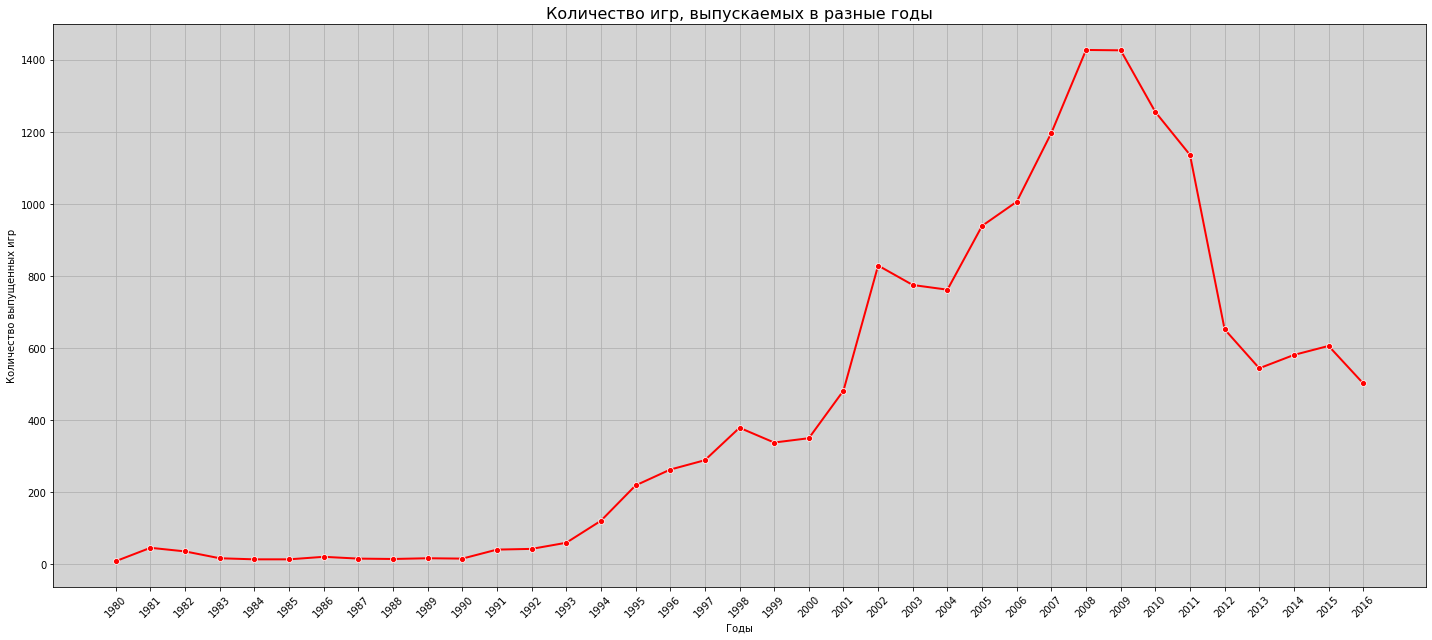

In [26]:
# построим график для наглядности
dynamics_by_year = games.groupby('year_of_release').size().reset_index(name='total_sales')

min_year = games['year_of_release'].min()
max_year = games['year_of_release'].max()
all_years = np.arange(min_year, max_year + 1)

plt.figure(figsize=(20, 9))
ax = sns.lineplot(
    data=dynamics_by_year,
    x='year_of_release',
    y='total_sales',
    marker='o',            
    linewidth=2,          
    color='red'
)

ax.set_facecolor('lightgray')

ax.set_title('Количество игр, выпускаемых в разные годы', fontsize=16)
ax.set_xlabel('Годы')
ax.set_ylabel('Количество выпущенных игр')

ax.set_xticks(all_years)
ax.set_xticklabels(all_years, rotation=45)
ax.grid(True)

plt.tight_layout()
plt.show()

In [27]:
# помотрим в каком году выпущено меньше всего игр и их количество, а также с максимальное количество игр и год
counts_by_year = games['year_of_release'].value_counts()

min_count = counts_by_year.min()
max_count = counts_by_year.max()

years_with_min = counts_by_year[counts_by_year == min_count].index.tolist()
years_with_max = counts_by_year[counts_by_year == max_count].index.tolist()

print(f"Минимальное количество игр выпущено в {years_with_min[0]} году(ах) и составляет {min_count} шт.")
print(f"Максимальное количество игр выпущено в {years_with_max[0]} году(ах) и составляет {max_count} шт.")

Минимальное количество игр выпущено в 1980 году(ах) и составляет 9 шт.
Максимальное количество игр выпущено в 2008 году(ах) и составляет 1427 шт.


что мы видим.  
на графике наглядно видно, что начиная с 1980 года по 1991 год развитие игр было слабым.  
начиная с 1991 года вплоть до 2009 года замечается значительный рост количества выпускаемых игр.  
рост связан с развитием игр и набора популярности у пользователей (компьютеры в эти годы стало проще покупать).  
после 2009 года количество выпускаемых игр сокращается, может быть связано с большой конкурентностью на рынке (разработчики стараются максимально улучшить игру, по-этому выпускают реже).  
минимальное количество (9 шт.) выпущено в 1980 году.   
максимальное количество (1.427 шт.) выпущено в 2008 году.  
данные за каждый период нам важны, так как прослеживается динамика разработки и выпуска игр.

<b>3.2. Продажи игр по платформам.</b>
<a id='3.2'></a> 

In [28]:
# посмотрим на количество платформ в нашем датасете
games['platform'].nunique()

31

In [29]:
# и их названия
games['platform'].unique()

array(['Wii', 'NES', 'GB', 'DS', 'X360', 'PS3', 'PS2', 'SNES', 'GBA',
       'PS4', '3DS', 'N64', 'PS', 'XB', 'PC', '2600', 'PSP', 'XOne',
       'WiiU', 'GC', 'GEN', 'DC', 'PSV', 'SAT', 'SCD', 'WS', 'NG', 'TG16',
       '3DO', 'GG', 'PCFX'], dtype=object)

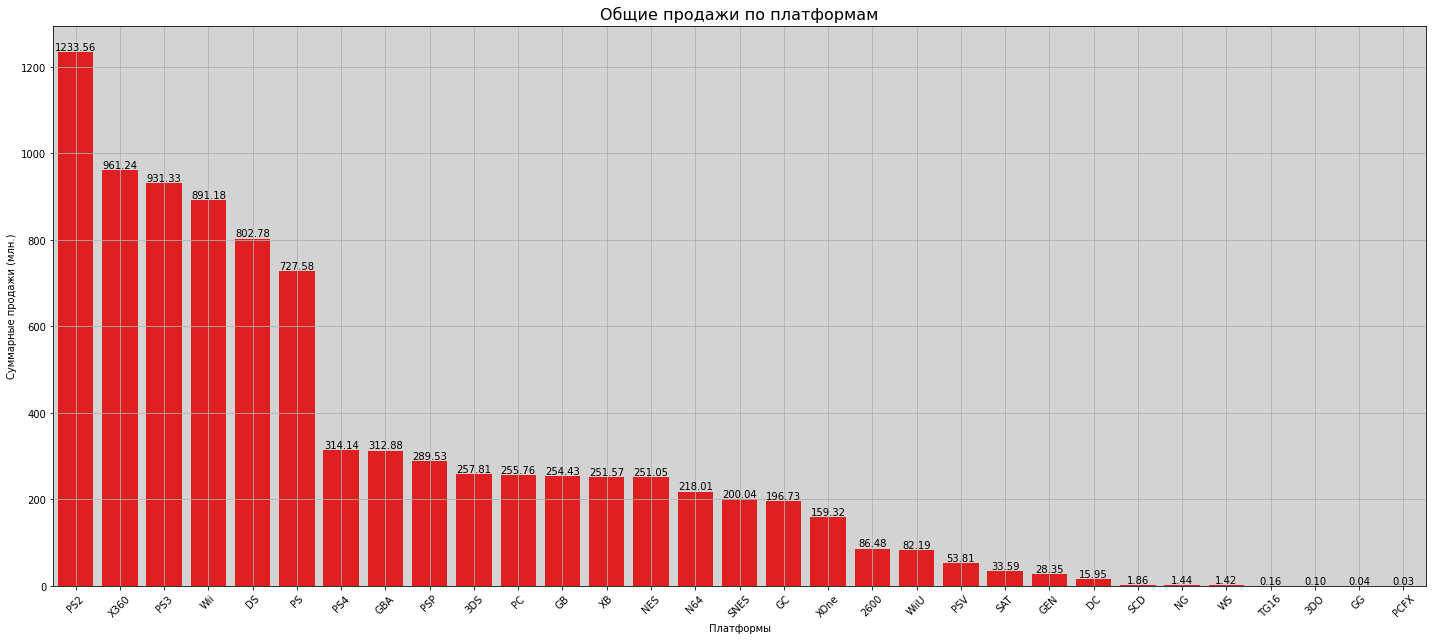

In [30]:
# построим график для наглядности
sales_by_platform = games.pivot_table(index='platform', values='total_sales', aggfunc='sum') \
                .sort_values(by='total_sales', ascending=False)

plt.figure(figsize=(20, 9))

ax = sns.barplot(
    x=sales_by_platform.index,
    y=sales_by_platform['total_sales'],
    color='red'
)

ax.set_facecolor('lightgray')

ax.set_title('Общие продажи по платформам', fontsize=16)
ax.set_xlabel('Платформы')
ax.set_ylabel('Суммарные продажи (млн.)')

plt.xticks(rotation=45)

ax.grid(True)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}',
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10)
    
plt.tight_layout()
plt.show()

что мы видим на графике.  
у нас есть неоспоримый лидер по продажам - платформа "PS2", более 1.233 миллионов проданных копий.  
после лидера относительно ровненько идут еще 5 платформ:  
    - на втором месте "X360" с более 961 миллионом проданных копий;  
    - на третем месте "РS3" с более 931 миллионом проданных копий;  
    - на четвертом месте "Wii" с более 891 миллионом проданных копий;  
    - на пятом месте "DS" с более 802 миллионами проданных копий;  
    - и на шестом месте "РS" с более 727 миллионов проданных копий.  
у оставшихся платформ продажи значительно ниже.  
лидеры по продажам определены, теперь посмотрим их распределения по годам.

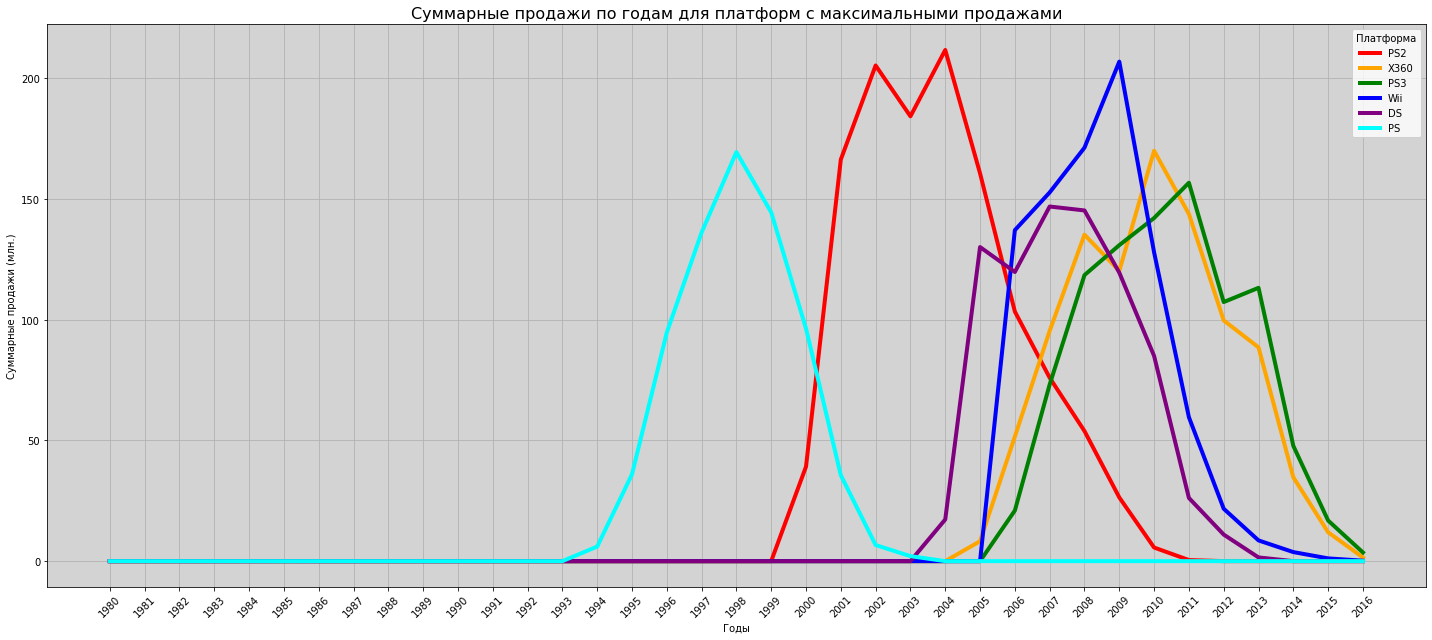

In [31]:
# построим график
top_platforms = (
    games
    .pivot_table(index='platform', values='total_sales', aggfunc='sum')
    .sort_values(by='total_sales', ascending=False)                 
    .head(6)                                                        
    .index                                                           
)

all_years = range(games['year_of_release'].min(), games['year_of_release'].max() + 1)

plt.figure(figsize=(20, 9))
ax = plt.gca()
ax.set_facecolor('lightgray')

colors = ['red', 'orange', 'green', 'blue', 'purple', 'cyan']

for i, b in enumerate(top_platforms):
    data = (
        games.query('platform == @b')
        .pivot_table(index='year_of_release', values='total_sales', aggfunc='sum')
        .reindex(all_years, fill_value=0)
    )
    data['total_sales'].plot(
        label=b,
        linewidth=4,
        color=colors[i % len(colors)]
    )

plt.title('Суммарные продажи по годам для платформ с максимальными продажами', fontsize=16)
plt.xlabel('Годы')
plt.ylabel('Суммарные продажи (млн.)')
plt.legend(title='Платформа')
plt.grid(True)

plt.xticks(all_years, rotation=45)

plt.tight_layout()
plt.show()

In [32]:
# посмотрим точно средний срок жизни платформы
temp = games.copy() 
time_life = temp.pivot_table(index='platform', values='year_of_release', aggfunc=['min', 'max']).reset_index()
time_life['life'] = time_life['max'] - time_life['min'] + 1 
time_life['life'].median()

7.0

что мы можем сказать по полученному графику.  
средний срок жизни платформы составляет 7 лет.  
популярности (пикового значения) каждая платформа достигает в среднем через 5 лет после выхода на рынок, после чего идет на спад, даже у лидеров нашего топа.  
+ у платформы "РS2" пик продаж приходится с 2002 года по 2004 год;  
+ у платформы "Х360" пик продаж был в 2010 году;  
+ у платформы "РS3" хорошие продажи были с 2008 года по 2011 год;  
+ у платформы "Wii" пик продаж был в 2009 году;  
+ у платформы "DS" хорошие продажи были с 2005 года по 2008 год;  
+ и у платформы "РS" пик приходится на 1998 год.  

и даже уже наши лидеры-платформы на данный момент не являются актуальными.

для прогнозирования продаж на 2017 год будем работать с актуальными данными за последние 3 года, то есть за 2014 год, 2015 год и 2016 год.  
данные за предыдущие года не будем учитывать.

In [33]:
# создадим отдельную таблицу с нашими актуальными данными
current_period = games.query('year_of_release >= 2014')

<b>3.3. Платформы - лидеры по продажам, растут или падают? Потенциально прибыльные платформы.</b>
<a id='3.3'></a> 

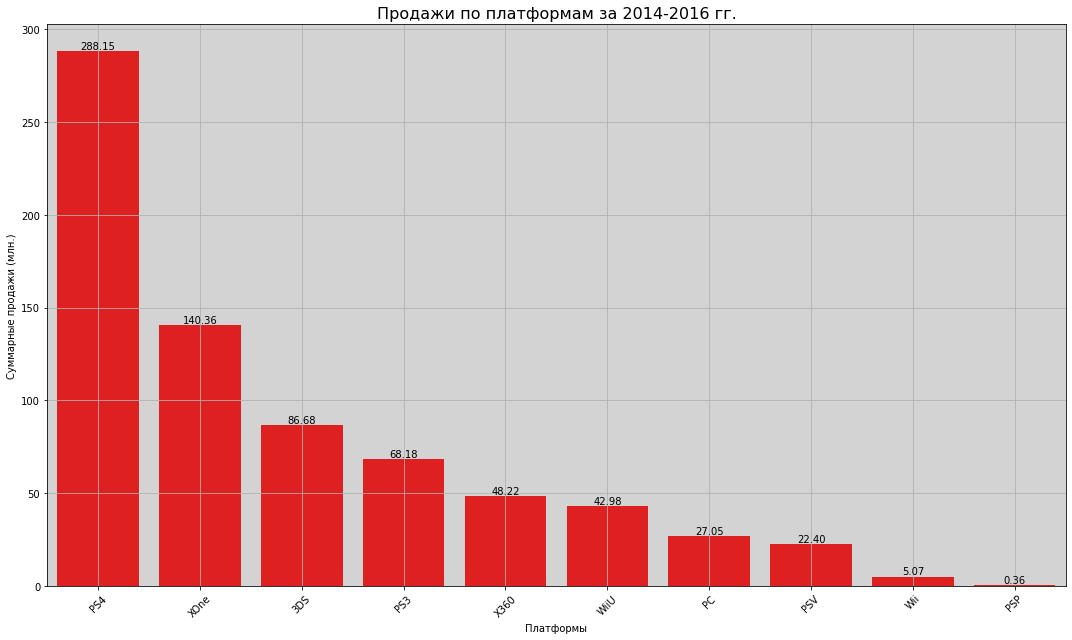

In [34]:
# посмотрим на графике какие платформы на актуальный период у нас лидируют
current_platform_sales = (
    current_period
    .pivot_table(index='platform', values='total_sales', aggfunc='sum')
    .sort_values('total_sales', ascending=False)
)
plt.figure(figsize=(15, 9))
ax = sns.barplot(
    data = current_platform_sales, 
    x = current_platform_sales.index, 
    y = 'total_sales', 
    color = 'red'
)

ax.set_facecolor('lightgray')

ax.set_title('Продажи по платформам за 2014-2016 гг.', fontsize=16)
ax.set_xlabel('Платформы')
ax.set_ylabel('Суммарные продажи (млн.)')

plt.xticks(rotation=45)

ax.grid(True)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}',
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10)
    
plt.tight_layout()
plt.show()

сразу отмечаем, что на актуальный период лидеры у нас поменялись.  
на актуальный период в лидерах по продажам у нас платформа "РS4" с продажами более 288 миллионов копий.  
на втором месте за актуальный период - платфора "XOne" с продажами более 140 миллионов копий.  
у остальных платформ показатели продаж значительно ниже.  

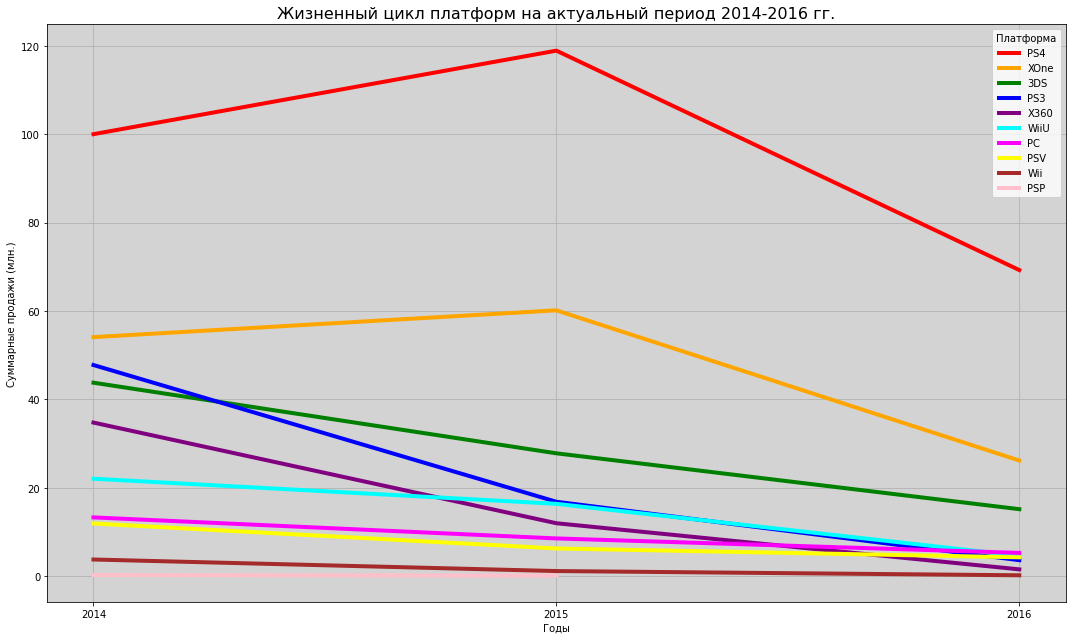

In [35]:
# теперь построим график "жизни" платформ на актуальный период
top_platforms = (
    current_period
    .pivot_table(index='platform', values='total_sales', aggfunc='sum')
    .sort_values('total_sales', ascending=False)
    .index
)


plt.figure(figsize=(15, 9))
ax = plt.gca()
ax.set_facecolor('lightgray')

colors = ['red', 'orange', 'green', 'blue', 'purple', 'cyan', 'magenta', 'yellow', 'brown', 'pink']

for i, platform in enumerate(top_platforms):
    data = (
        current_period.query('platform == @platform')
        .pivot_table(index='year_of_release', values='total_sales', aggfunc='sum')
    )
    data['total_sales'].plot(
        label=platform,
        linewidth=4,
        color=colors[i % len(colors)]
    )

plt.title('Жизненный цикл платформ на актуальный период 2014-2016 гг.', fontsize=16)
plt.xlabel('Годы')
plt.ylabel('Суммарные продажи (млн.)')
plt.legend(title='Платформа')
plt.grid(True)
plt.xticks([2014, 2015, 2016])

plt.tight_layout()
plt.show()

что мы видим на графике.  
картина выгядит негативно в целом для всех платформ.  
свою привлекательность потеряли платформы: "3DS", "PS3", "Х360", "WiiU", "РС", "PSV", "Wii" и "PSP".  
оставшиеся платформы "PS4" и "XOne" оставляют надежды хотя бы на непадение своей популярности, их можно считать потенциально прибыльными платформами.

In [36]:
# сделаем табличку потенциальнно прибыльных платформ на актуальный период
current_platforms = current_period.query('platform not in ["3DS", "PS3", "X360", "WiiU", "PC", "PSV", "Wii", "PSP"]')

<b>3.4. «Ящик с усами» по глобальным продажам игр в разбивке по платформам.</b>
<a id='3.4'></a> 

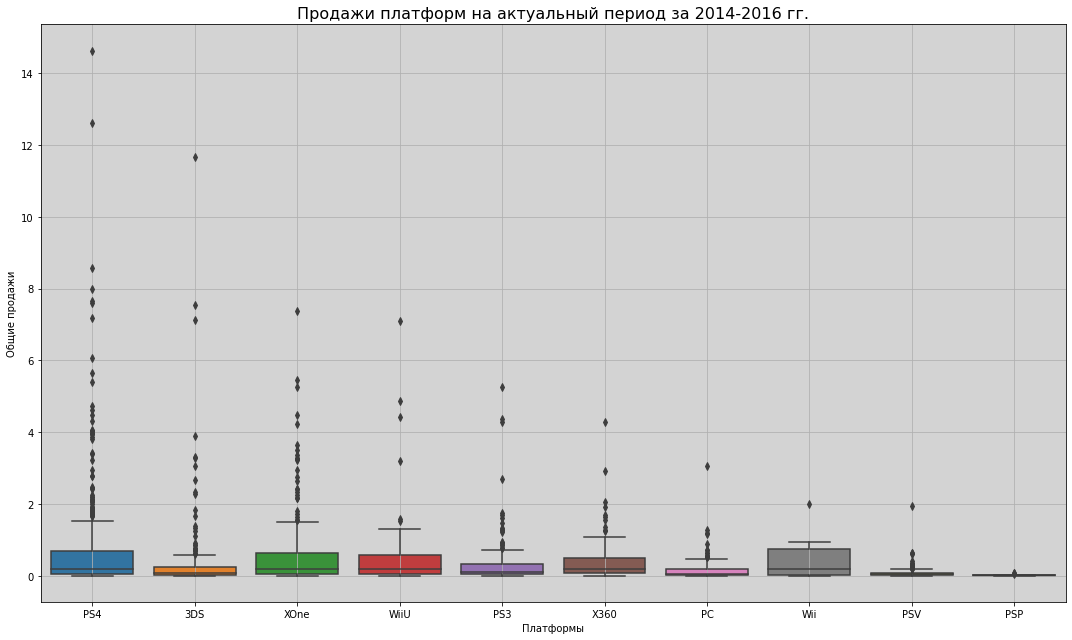

In [37]:
# сначала построим "ящик с усами" со всеми платформами на актуальный период
plt.figure(figsize=(15, 9))
ax = sns.boxplot(data=current_period, y='total_sales', x='platform')

ax.set_title('Продажи платформ на актуальный период за 2014-2016 гг.', fontsize=16)
ax.set_xlabel('Платформы')
ax.set_ylabel('Общие продажи')
ax.grid(True)
ax.set_facecolor('lightgray')

plt.tight_layout()
plt.show()

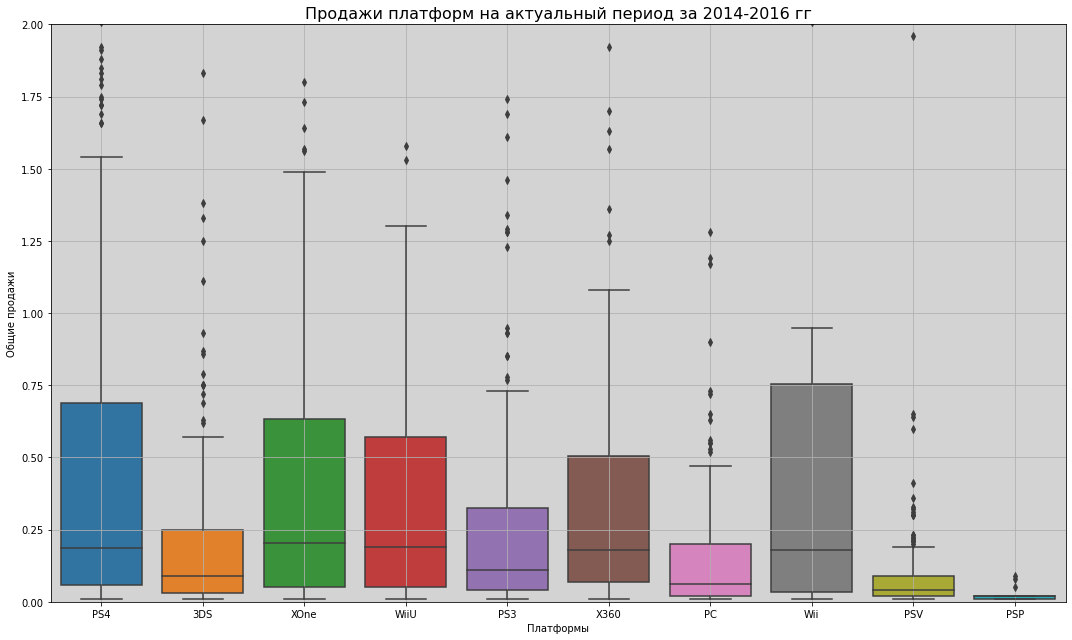

In [38]:
# то же самое, но с ограничением 
plt.figure(figsize=(15, 9))
ax = sns.boxplot(data=current_period, y='total_sales', x='platform')

ax.set_title('Продажи платформ на актуальный период за 2014-2016 гг', fontsize=16)
ax.set_xlabel('Платформы')
ax.set_ylabel('Общие продажи')
ax.set_ylim(0, 2)
ax.grid(True)
ax.set_facecolor('lightgray')

plt.tight_layout()
plt.show()

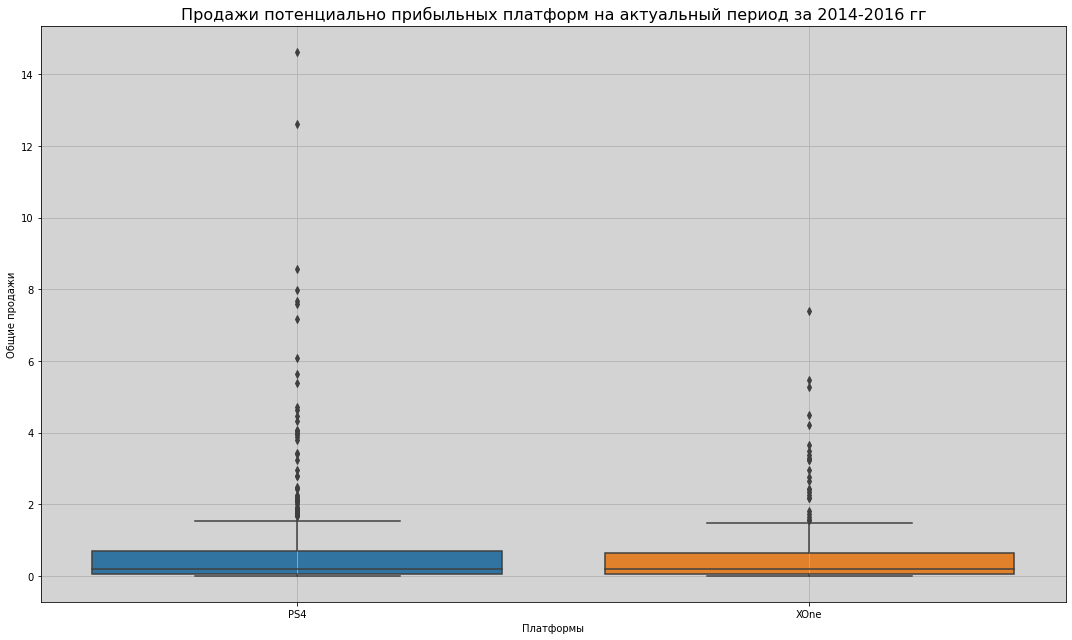

In [39]:
# теперь посстроим "ящик с усами" для потенциально прибыльных платформ за актуальный период
plt.figure(figsize=(15, 9))
ax = sns.boxplot(data=current_platforms, y='total_sales', x='platform')

ax.set_title('Продажи потенциально прибыльных платформ на актуальный период за 2014-2016 гг', fontsize=16)
ax.set_xlabel('Платформы')
ax.set_ylabel('Общие продажи')
ax.grid(True)
ax.set_facecolor('lightgray')

plt.tight_layout()
plt.show()

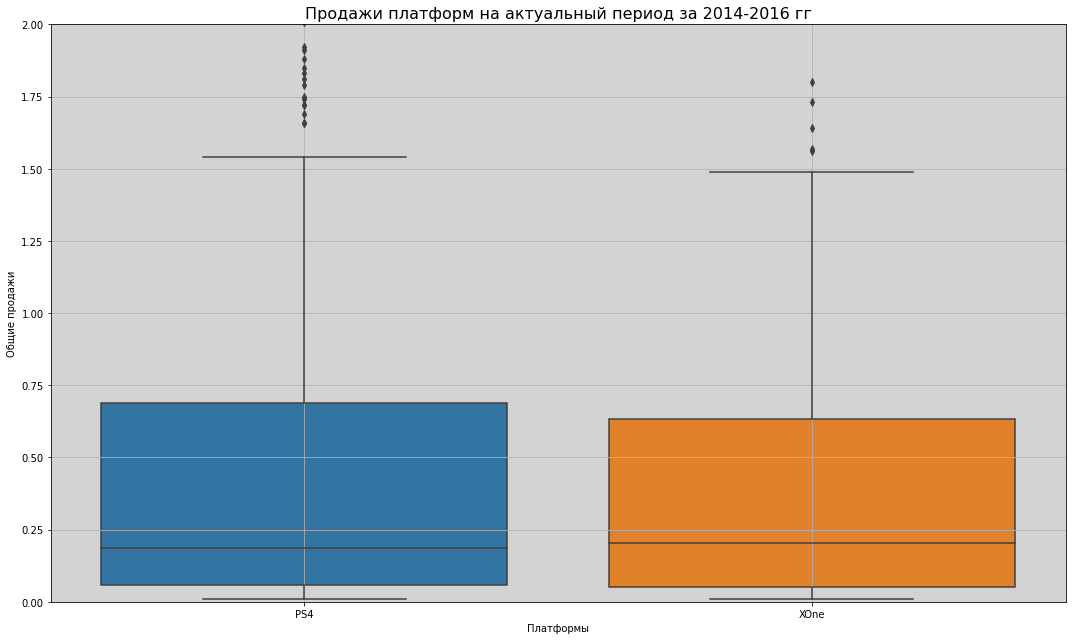

In [40]:
# то же самое, но с ограничением
plt.figure(figsize=(15, 9))
ax = sns.boxplot(data=current_platforms, y='total_sales', x='platform')

ax.set_title('Продажи платформ на актуальный период за 2014-2016 гг', fontsize=16)
ax.set_xlabel('Платформы')
ax.set_ylabel('Общие продажи')
ax.set_ylim(0, 2)
ax.grid(True)
ax.set_facecolor('lightgray')

plt.tight_layout()
plt.show()

что мы можем сказать по полученным графикам.  
все платформы имеют выбросы.  
распределение продаж среди платформ примерно одинаковое.  
медиана продаж у всех находится примерно на одном уровне (0.2).  

<b>3.5. Влияние отзывов пользователей и критиков на продажи внутри одной популярной платформы. Диаграмма рассеяния и подсчет корреляции между отзывами и продажами.</b>
<a id='3.5'></a> 

самая популярная платформа на актуальный период у нас "PS4", с ней и будем работать.

In [41]:
print(len(current_period.query("critic_score != -1")))
print(len(current_period.query("user_score != -1")))
print(len(current_period.query("critic_score != -1 & user_score != -1")))

718
888
704


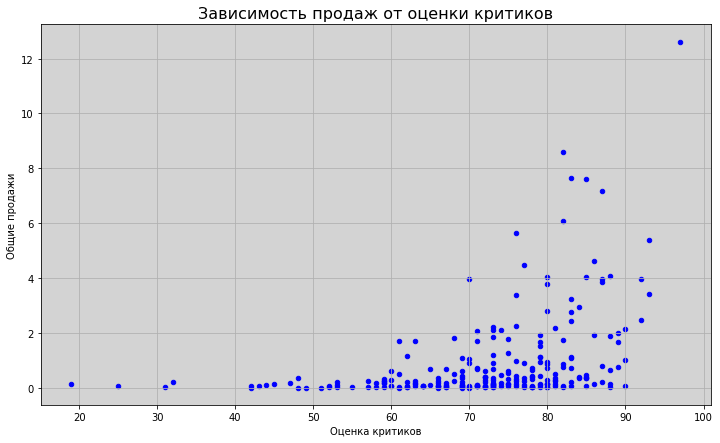

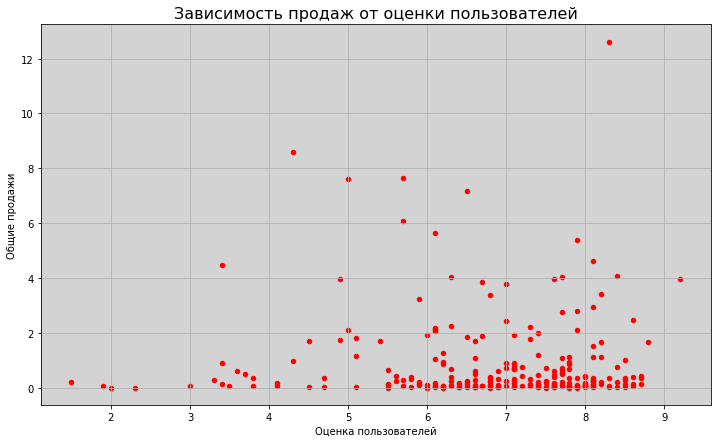

critic_score   0.40
total_sales    1.00
Name: total_sales, dtype: float64
user_score    -0.04
total_sales    1.00
Name: total_sales, dtype: float64


In [42]:
# отфильтруем данные для оценок критиков и пользователей отдельно
platform_ps4_critic = current_platforms.query('platform == "PS4" & critic_score != -1')
platform_ps4_user = current_platforms.query('platform == "PS4" & user_score != -1')

# график зависимости продаж от оценки критиков
ax1 = platform_ps4_critic.plot(
    kind='scatter',
    x='critic_score',
    y='total_sales',
    figsize=(12, 7),
    color='blue'
)
ax1.set_facecolor('lightgray')
ax1.set_title('Зависимость продаж от оценки критиков', fontsize=16)
ax1.set_xlabel('Оценка критиков')         
ax1.set_ylabel('Общие продажи')
ax1.grid(True)

# график зависимости продаж от оценки пользователей
ax2 = platform_ps4_user.plot(
    kind='scatter',
    x='user_score',
    y='total_sales',
    figsize=(12, 7),
    color='red'
)
ax2.set_facecolor('lightgray')
ax2.set_title('Зависимость продаж от оценки пользователей', fontsize=16)
ax2.set_xlabel('Оценка пользователей')         
ax2.set_ylabel('Общие продажи')
ax2.grid(True)

plt.show()

print(platform_ps4_critic[['critic_score', 'total_sales']].corr()['total_sales'])
print(platform_ps4_user[['user_score', 'total_sales']].corr()['total_sales'])

что мы можем сказать.  
рейтинг критиков и продажи имеют корреляцию около 40, можно сказать, что существует положительная связь между рейтингом критиков и продажами, чем выше оценка критиков, тем лучше продажи.  
рейтинг пользователей можно сказать, что вообще никак не влияет на продажи.
в целом рейтинги — не единственный или главный фактор, влияющий на продажи игр.

<b>3.6. Соотнесение выводов с продажами игр на других платформах.</b>
<a id='3.6'></a> 

рассмотрим еще 4 платформы: "XOne", "3DS", "PS3" и "Х360"

In [43]:
# сначала зададим функцию
def plot_platform_relationships(data, platform_name):
    # отфильтруем данные для платформы
    platform_data = data.query('platform == @platform_name')

    # отфильтруем данные для оценки критиков
    critic_data = platform_data[platform_data['critic_score'] != -1]
    ax1 = critic_data.plot(
        kind='scatter',
        x='critic_score',
        y='total_sales',
        figsize=(12, 7),
        color='blue'
    )
    ax1.set_facecolor('lightgray')
    ax1.set_title(f'Зависимость продаж от оценки критиков ({platform_name})', fontsize=16)
    ax1.set_xlabel('Оценка критиков')         
    ax1.set_ylabel('Общие продажи')
    ax1.grid(True)

    # отфильтруем данные для оценки пользователей
    user_data = platform_data[platform_data['user_score'] != -1]
    ax2 = user_data.plot(
        kind='scatter',
        x='user_score',
        y='total_sales',
        figsize=(12, 7),
        color='red'
    )
    ax2.set_facecolor('lightgray')
    ax2.set_title(f'Зависимость продаж от оценки пользователей ({platform_name})', fontsize=16)
    ax2.set_xlabel('Оценка пользователей')         
    ax2.set_ylabel('Общие продажи')
    ax2.grid(True)

    plt.show()

    # рассчитаем корреляцию для оценок критиков
    critic_corr = critic_data[['critic_score', 'total_sales']].corr()['total_sales']
    # рассчитаем корреляцию для оценок пользователей
    user_corr = user_data[['user_score', 'total_sales']].corr()['total_sales']
    
    print(f"Коэффициенты корреляции для платформы {platform_name}:")
    print("Коэффициенты корреляции для оценок критиков:")
    print(critic_corr)
    print("Коэффициенты корреляции для оценок пользователей:")
    print(user_corr)

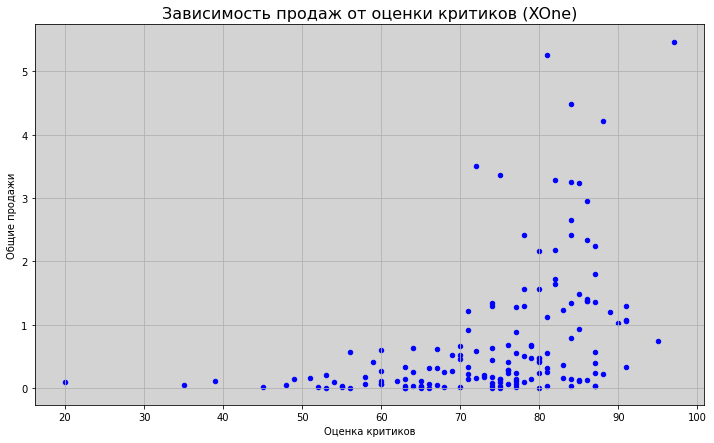

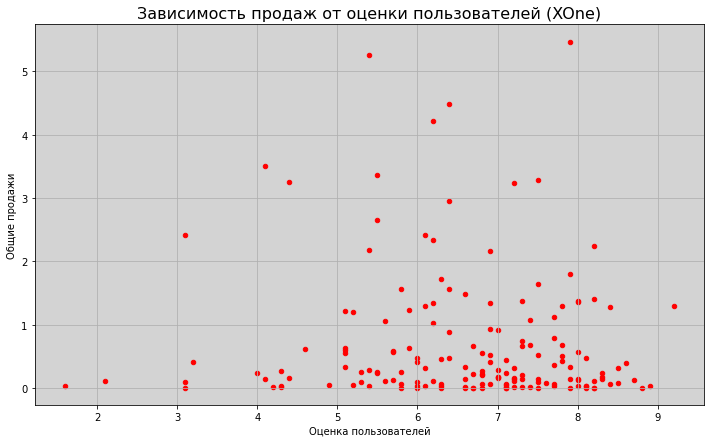

Коэффициенты корреляции для платформы XOne:
Коэффициенты корреляции для оценок критиков:
critic_score   0.43
total_sales    1.00
Name: total_sales, dtype: float64
Коэффициенты корреляции для оценок пользователей:
user_score    -0.07
total_sales    1.00
Name: total_sales, dtype: float64


In [44]:
plot_platform_relationships(current_period, 'XOne')

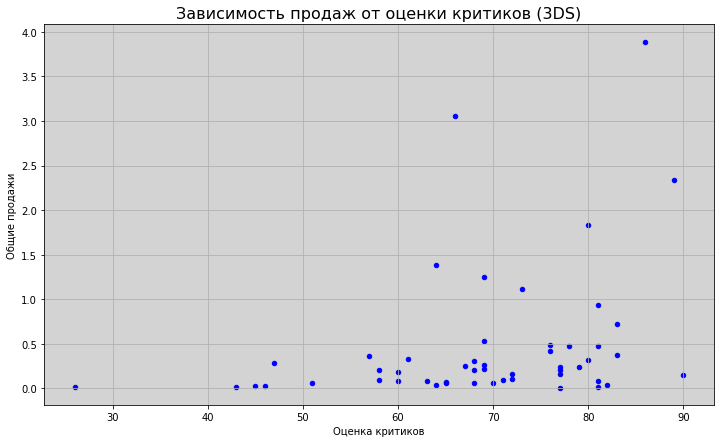

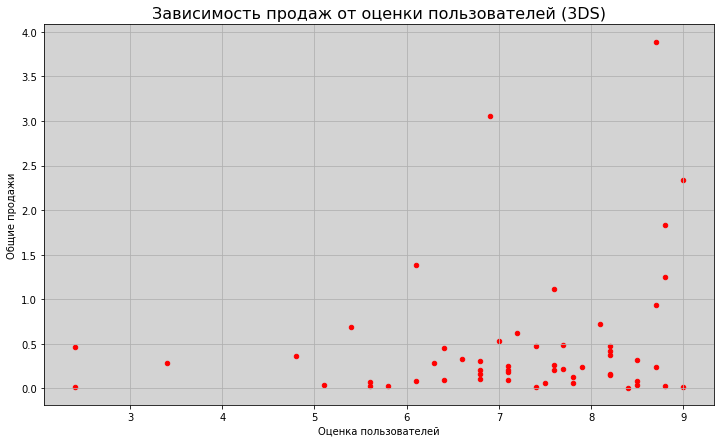

Коэффициенты корреляции для платформы 3DS:
Коэффициенты корреляции для оценок критиков:
critic_score   0.31
total_sales    1.00
Name: total_sales, dtype: float64
Коэффициенты корреляции для оценок пользователей:
user_score    0.22
total_sales   1.00
Name: total_sales, dtype: float64


In [45]:
plot_platform_relationships(current_period, '3DS')

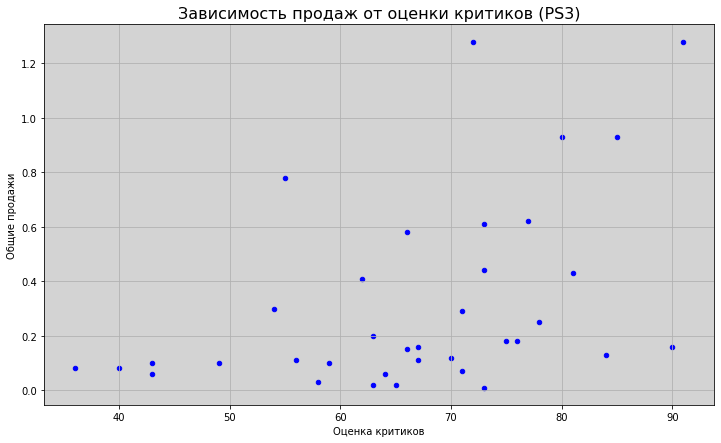

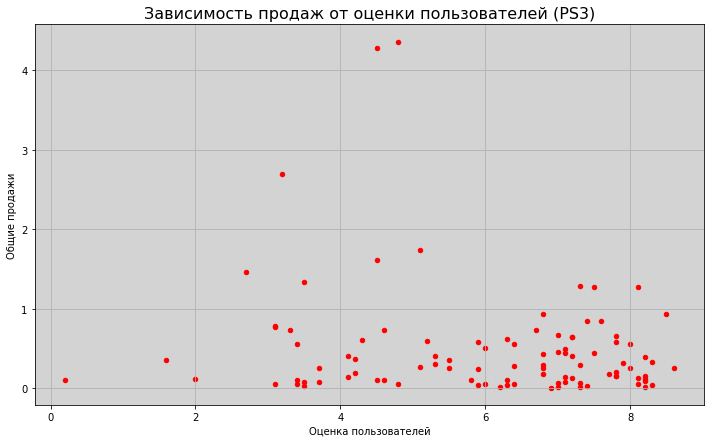

Коэффициенты корреляции для платформы PS3:
Коэффициенты корреляции для оценок критиков:
critic_score   0.45
total_sales    1.00
Name: total_sales, dtype: float64
Коэффициенты корреляции для оценок пользователей:
user_score    -0.17
total_sales    1.00
Name: total_sales, dtype: float64


In [46]:
plot_platform_relationships(current_period, 'PS3')

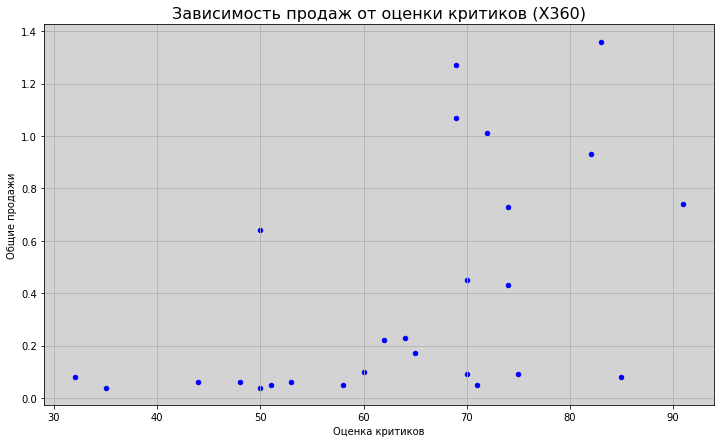

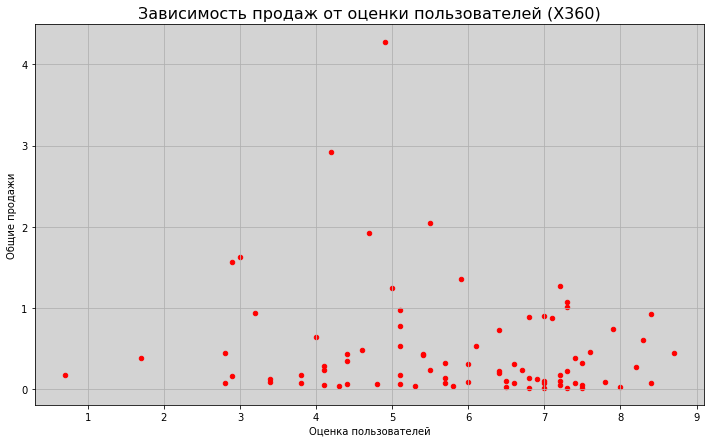

Коэффициенты корреляции для платформы X360:
Коэффициенты корреляции для оценок критиков:
critic_score   0.53
total_sales    1.00
Name: total_sales, dtype: float64
Коэффициенты корреляции для оценок пользователей:
user_score    -0.14
total_sales    1.00
Name: total_sales, dtype: float64


In [47]:
plot_platform_relationships(current_period, 'X360')

In [48]:
# и то же самое с оценками критиков
current_period.query('critic_score > -1')['critic_score'].corr(current_period['total_sales'])

0.328105086966363

In [49]:
# посмотрим общее сравнение оценок пользователей с продажами за актуальный период
current_period.query('user_score > -1')['user_score'].corr(current_period['total_sales'])

-0.013070305002484585

что мы можем сказать.  
как и в случае с платформой "PS4", другие платформы показывают относительно похожие результаты.   
оценка критиков оказывает влияние на продажи, у рассмотренных нами корреляция больше 30%, в случае платформы "Х360" так вообще все 53%.  
по поводу оценок пользователей корреляция во всех случаях не более 22%, что говорит о ничтожно малой зависимости с продажами.  
в целом можно сказать, что к мнению критиков люди прислушиваются больше.

<b>3.7. Общее распределение игр по жанрам.</b>
<a id='3.7'></a> 

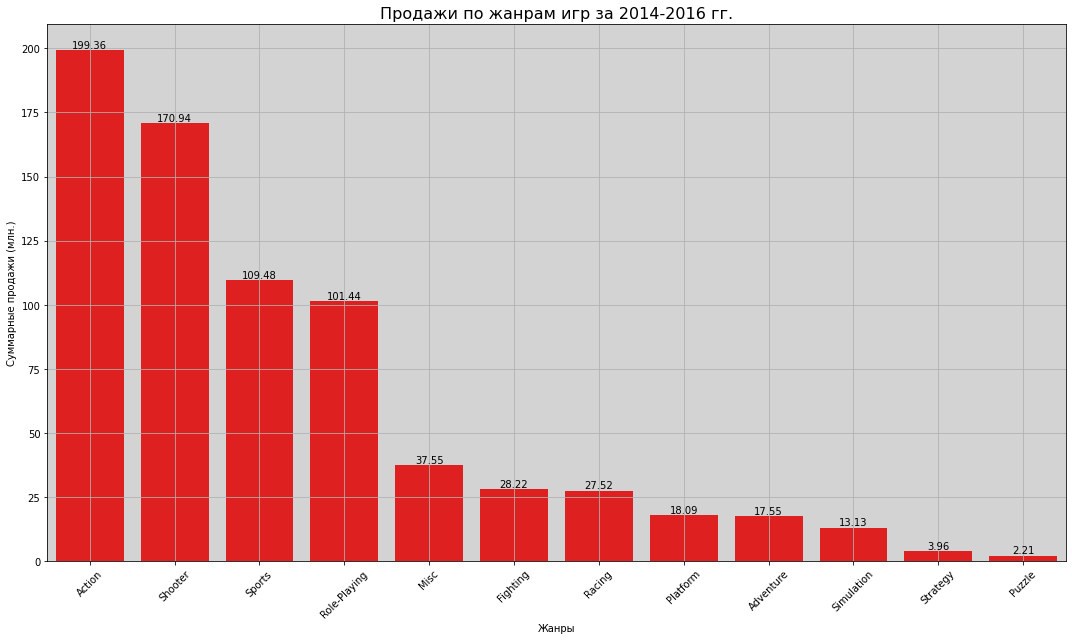

In [50]:
genre_in_current_period = (
    current_period
    .pivot_table(index='genre', values='total_sales', aggfunc='sum')
    .sort_values('total_sales', ascending=False)
)

plt.figure(figsize=(15, 9))
ax = sns.barplot(
    data = genre_in_current_period, 
    x = genre_in_current_period.index, 
    y = 'total_sales', 
    color = 'red'
)

ax.set_facecolor('lightgray')

ax.set_title('Продажи по жанрам игр за 2014-2016 гг.', fontsize=16)
ax.set_xlabel('Жанры')
ax.set_ylabel('Суммарные продажи (млн.)')

plt.xticks(rotation=45)

ax.grid(True)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}',
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10)
    
plt.tight_layout()
plt.show()

что видим на графике.  
самые продаваемые игры идут в жанре "Action" более 199 миллионов проданных копий.  
затем идет жанр "Shooter" со 170 миллионами проданных копий.  
на третем месте жанр "Sports" со 109 миллионами проданных копий.  
и еще можно выделить жанр "Role-Playing" с более чем 101 миллионом проданных копий.  
остальные жанры имеют показатели значительно ниже.  

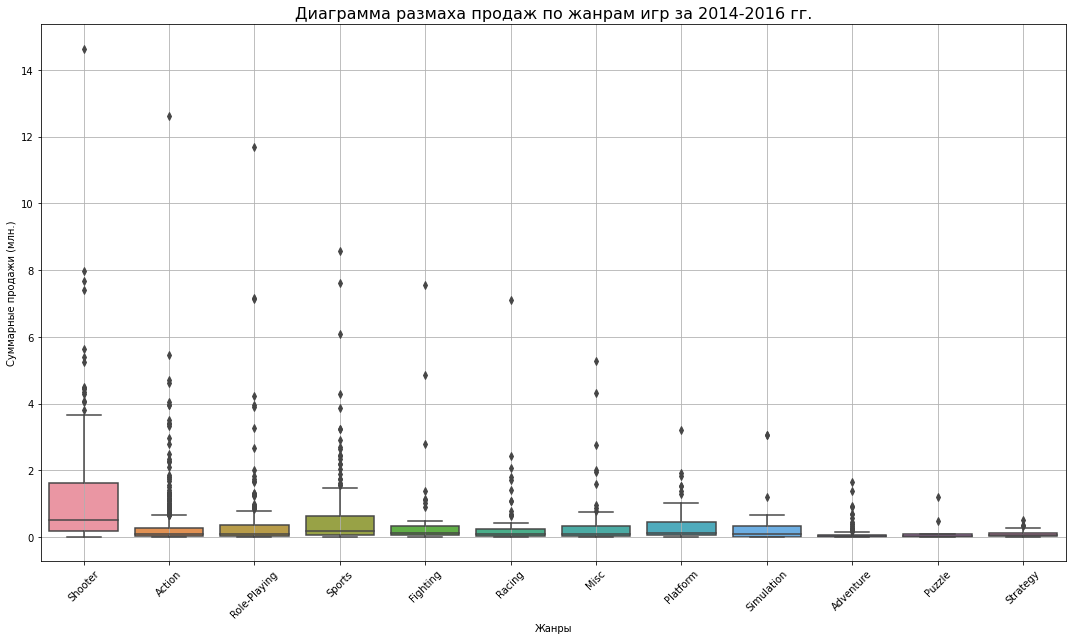

Медианные продажи по жанрам:
           genre  total_sales
8        Shooter         0.52
10        Sports         0.18
4       Platform         0.14
2       Fighting         0.12
7   Role-Playing         0.11
9     Simulation         0.10
0         Action         0.09
3           Misc         0.09
6         Racing         0.09
11      Strategy         0.06
5         Puzzle         0.04
1      Adventure         0.03


In [51]:
# рассчитаем медианные продажи по жанрам
median_sales_by_genre = (
    current_period
    .groupby('genre')['total_sales']
    .median()
    .reset_index()
)

# строим диаграмму размаха для визуализации 
plt.figure(figsize=(15, 9))
sns.boxplot(data=current_period, x='genre', y='total_sales')

plt.title('Диаграмма размаха продаж по жанрам игр за 2014-2016 гг.', fontsize=16)
plt.xlabel('Жанры')
plt.ylabel('Суммарные продажи (млн.)')

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

# выводим медианные продажи для анализа
print("Медианные продажи по жанрам:")
print(median_sales_by_genre.sort_values('total_sales', ascending=False))

что можно сказать полагаясь на медианные продажи по жанрам.  
+ лидер по медианным продажам за актуавльный период - жанр игры "Shooter" (0.52 миллионов проданных копий), высокая популярность и устойчивый спрос, следовательно продажи выше, чем у других жанров;
+ на втором месте расположился жанр игры "Sports", хоть и показатель медианных продаж значительно ниже, чем у жанра "Shooter", но тем не менее тоже пользуется стабильным интересом у пользователей (0.18 миллионов проданных копий) за актуальный период;  
+ самые низкие медианные продажи у нас показывают такие жанры как: ""Adventure", "Puzzle" и "Strategy" (0.03, 0.04 и 0.06 миллионов проданных копий соответственно).

<b>3.8. Вывод.</b>
<a id='3.8'></a> 

<u>В исследовательском анализе данных было сделано следующее:</u>  


1. Мы рассмотрели динамику выпуска количества игр по годам.  
С 1980 года по 1991 год развитие игр было слабым, начиная с 1991 года вплоть до 2009 года отметили значительный рост количества выпускаемых игр, рост связан с развитием игр и набора популярности у пользователей (компьютеры в эти годы стало проще покупать). После 2009 года количество выпускаемых игр сокращается, может быть связано с большой конкурентностью на рынке (разработчики стараются максимально улучшить игру, по-этому выпускают реже).
Минимальное количество игр (9 шт.) выпущено в 1980 году.
Максимальное количество игр (1.427 шт.) выпущено в 2008 году.
Данные за каждый период нам важны, так как прослеживается динамика разработки и выпуска игр.
  
  
2. Рассмотрели динамику продаж по платформам:  
Определили неоспоримого лидера по продажам - платформа "PS2", более 1.233 миллионов проданных копий, далее
- на втором месте "X360" с более 961 миллионом проданных копий;  
- на третем месте "РS3" с более 931 миллионом проданных копий;  
- на четвертом месте "Wii" с более 891 миллионом проданных копий;  
- на пятом месте "DS" с более 802 миллионами проданных копий;  
- и на шестом месте "РS" с более 727 миллионов проданных копий.  
У оставшихся платформ продажи значительно ниже.
После определения этих 6 лидеров мы смотрели их распределения по годам и определили, что средний срок жизни платформы составляет 10 лет, в среднем популярности (пикового значения) каждая платформа достигает в среднем через 5 лет после выхода на рынок, после чего идет на спад.  
+ у платформы "РS2" пик продаж приходится с 2002 года по 2004 год;
+ у платформы "Х360" пик продаж был в 2010 году;
+ у платформы "РS3" хорошие продажи были с 2008 года по 2011 год;
+ у платформы "Wii" пик продаж был в 2009 году;
+ у платформы "DS" хорошие продажи были с 2005 года по 2008 год;
+ и у платформы "РS" пик приходится на 1998 год.
и даже уже наши лидеры-платформы на данный момент не являются актуальными.
    
     
3. Для прогназирования продаж на 2017 год нами был выбран актуальный период для исследования - последние 3 года (2014 год, 2015 год и 2016 год). На актуальный период в лидерах по продажам у нас платформа "РS4" с продажами более 288 миллионов копий. На втором месте за актуальный период - платфора "XOne" с продажами более 140 миллионов копий. У остальных платформ показатели продаж значительно ниже. Картина выгядит негативно в целом для всех платформ. Свою привлекательность потеряли платформы: "3DS", "PS3", "Х360", "WiiU", "РС", "PSV", "Wii" и "PSP". Оставшиеся платформы "PS4" и "XOne" оставляют надежды хотя бы на непадение своей популярности, их мы и считаем потенциально прибыльными платформами.
  
  
4. После построения "ящика с усами" по глобальным продажам в разбивке по платформам отметили следующее:  
+ все платформы имеют выбросы;  
+ распределение продаж среди платформ примерно одинаковое;
+ медиана продаж у всех находится примерно на одном уровне (0.2) 
       
       
5. Для оценки влияния отзывов пользователей и критиков на продажи внутри одной популярной платформы мы выбрали платформу "PS4". Построили диаграммы рассеивания, а также подсчитали результаты. и получили следующее: рейтинг критиков и продажи имеют корреляцию около 40, можно сказать, что существует положительная связь между рейтингом критиков и продажами, чем выше оценка критиков, тем лучше продажи, а вот про рейтинг пользователей можно сказать, что вообще никак не влияет на продажи. в целом рейтинги — не единственный или главный фактор, влияющий на продажи игр.
    
    
6. Также нами были рассмотрены еще 4 менее популярные платформы: "XOne", "3DS", "PS3" и "Х360". И при сравнении с лидером-платформой "PS4" разницы особо нет. Оценка критиков также оказывает влияние на продажи, у рассмотренных нами корреляция больше 30%, в случае платформы "Х360" так вообще все 53%. По поводу оценок пользователей корреляция во всех случаях меньше 22%, что говорит о ничтожно малой зависимости с продажами. В целом можно сказать, что к мнению критиков люди прислушиваются больше.
    
    
7. При распределении игр по жанрам (распределяли по медианным продажам за актуальный период) выявили следующее:  
+ лидер по медианным продажам за актуавльный период - жанр игры "Shooter" (0.52 миллионов проданных копий), высокая популярность и устойчивый спрос, следовательно продажи выше, чем у других жанров;  
+ на втором месте расположился жанр игры "Sports", хоть и показатель медианных продаж значительно ниже, чем у жанра "Shooter", но тем не менее тоже пользуется стабильным интересом у пользователей (0.18 миллионов проданных копий) за актуальный период;  
+ самые низкие медианные продажи у нас показывают такие жанры как: ""Adventure", "Puzzle" и "Strategy" (0.03, 0.04 и 0.06 миллионов проданных копий соответственно).

<h1>4. Портрет пользователя каждого региона.</h1>
<a id='4'></a>

<b>4.1. Самые популярные платформы (топ-5).</b>
<a id='4.1'></a> 

In [52]:
na = current_period[current_period.year_of_release >= 2014].groupby('platform')['na_sales'].agg(na_sales='sum').nlargest(5, 'na_sales').reset_index()
eu = current_period[current_period.year_of_release >= 2014].groupby('platform')['eu_sales'].agg(eu_sales='sum').nlargest(5, 'eu_sales').reset_index()
jp = current_period[current_period.year_of_release >= 2014].groupby('platform')['jp_sales'].agg(jp_sales='sum').nlargest(5, 'jp_sales').reset_index()

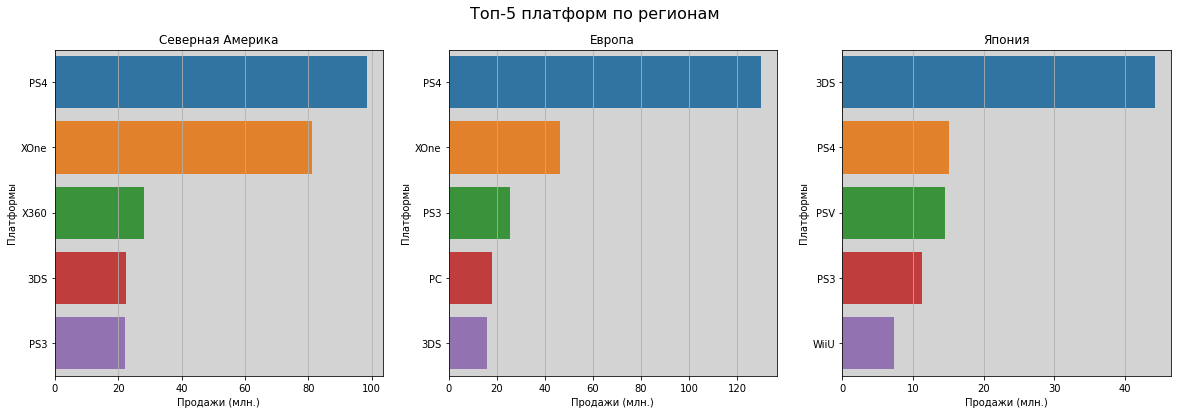

In [53]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Топ-5 платформ по регионам', fontsize=16)

# Северная Америка
sns.barplot(y='platform', x='na_sales', data=na, ax=ax[0])
ax[0].set_title('Северная Америка')
ax[0].set_xlabel('Продажи (млн.)')
ax[0].set_ylabel('Платформы')
ax[0].grid(axis='x')
ax[0].set_facecolor('lightgray')

# Европа
sns.barplot(y='platform', x='eu_sales', data=eu, ax=ax[1])
ax[1].set_title('Европа')
ax[1].set_xlabel('Продажи (млн.)')
ax[1].set_ylabel('Платформы')
ax[1].grid(axis='x')
ax[1].set_facecolor('lightgray')

# Япония
sns.barplot(y='platform', x='jp_sales', data=jp, ax=ax[2])
ax[2].set_title('Япония')
ax[2].set_xlabel('Продажи (млн.)')
ax[2].set_ylabel('Платформы')
ax[2].grid(axis='x')
ax[2].set_facecolor('lightgray')

plt.show()

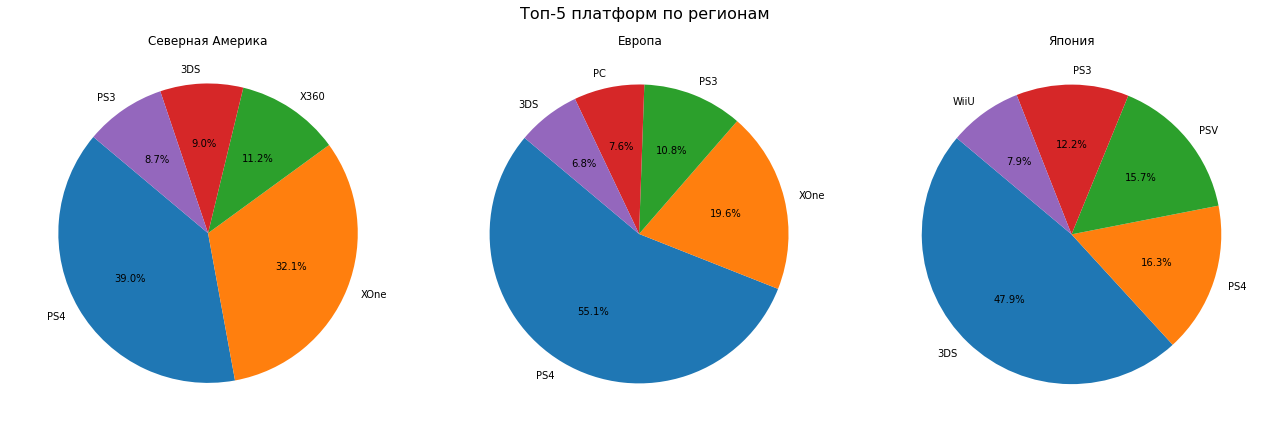

In [54]:
# для наглядности предлагаю еще рассмотреть круговые диаграммы в процентном соотношении
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Топ-5 платформ по регионам', fontsize=16)

# Северная Америка
axes[0].pie(
    na['na_sales'],
    labels=na['platform'],
    autopct='%1.1f%%',
    startangle=140
)
axes[0].set_title('Северная Америка')

# Европа
axes[1].pie(
    eu['eu_sales'],
    labels=eu['platform'],
    autopct='%1.1f%%',
    startangle=140
)
axes[1].set_title('Европа')

# Япония
axes[2].pie(
    jp['jp_sales'],
    labels=jp['platform'],
    autopct='%1.1f%%',
    startangle=140
)
axes[2].set_title('Япония')

for ax in axes:
    ax.axis('equal')

plt.tight_layout()
plt.show()

что мы можем сказать, полагаясь на полученные графики.  
мы рассмотрели одни из популярных платформ на актуальный период.  
разница среди регионов ощутима.  
отметим схожесть в предпочтении пользователей лидеров платформ у Северной Америки и Европы.  
в этих регионах платформы расположись:  
    - на первом месте платформа "PS4" (но процентное соотношение отличается (у СА - 39.0%, у Е - 55.1%));  
    - на втором месте платформа "XOne" (у СА - 32.1%, у Е - 19.6%);  
затем картина меняется.  
в Северное Америке на третем месте платформа "Х360" с 11.2%, на четвертом платформа "3DS" с 9.0%, и завершает платформа "PS3" с 8.7%.  
в Европе на третем месте расположилась платформа "PS3" с 10.8%, на четвртом платформа "РС" с 7.6%, и замыкает платформа "3DS" с 6.8%.
в Японии совершенно другая ситуация, в лидерах в 47.9% пользователи предпочитают платформу "3DS", на втором месте "PS4" с 16.3%, на третем платформу "PSV" с 15.7%, на четвертом платформу "PS3" с 12.2%, и в заключении платформу "WiiU" с 7.9%.

<b>4.2. Самые популярные жанры (топ-5).</b>
<a id='4.2'></a> 

In [55]:
na = current_period[current_period.year_of_release >= 2014].groupby('genre')['na_sales'].agg(na_sales='sum').nlargest(5, 'na_sales').reset_index()
eu = current_period[current_period.year_of_release >= 2014].groupby('genre')['eu_sales'].agg(eu_sales='sum').nlargest(5, 'eu_sales').reset_index()
jp = current_period[current_period.year_of_release >= 2014].groupby('genre')['jp_sales'].agg(jp_sales='sum').nlargest(5, 'jp_sales').reset_index()

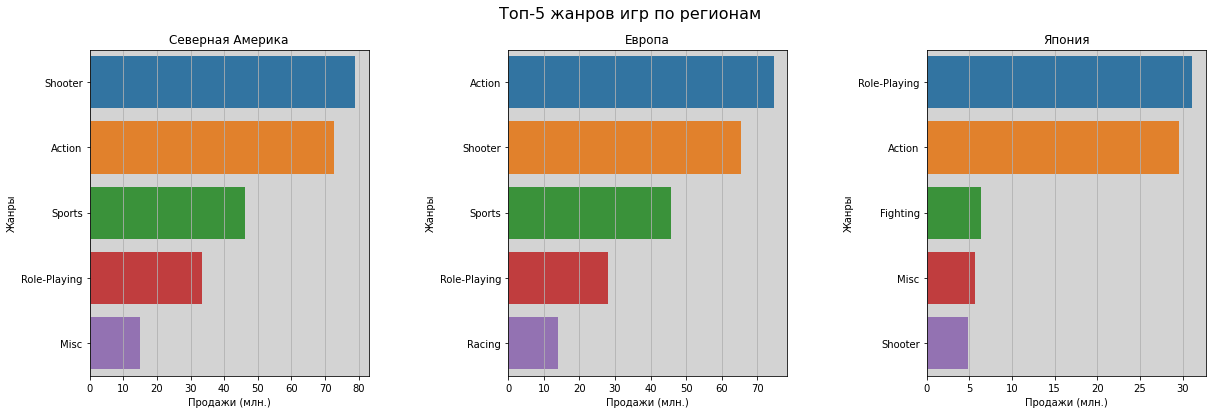

In [56]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Топ-5 жанров игр по регионам', fontsize=16)
plt.subplots_adjust(wspace=0.5)

# Северная Америка
sns.barplot(y='genre', x='na_sales', data=na, ax=ax[0])
ax[0].set_title('Северная Америка')
ax[0].set_xlabel('Продажи (млн.)')
ax[0].set_ylabel('Жанры')
ax[0].grid(axis='x')
ax[0].set_facecolor('lightgray')

# Европа
sns.barplot(y='genre', x='eu_sales', data=eu, ax=ax[1])
ax[1].set_title('Европа')
ax[1].set_xlabel('Продажи (млн.)')
ax[1].set_ylabel('Жанры')
ax[1].grid(axis='x')
ax[1].set_facecolor('lightgray')

# Япония
sns.barplot(y='genre', x='jp_sales', data=jp, ax=ax[2])
ax[2].set_title('Япония')
ax[2].set_xlabel('Продажи (млн.)')
ax[2].set_ylabel('Жанры')
ax[2].grid(axis='x')
ax[2].set_facecolor('lightgray')

plt.show()

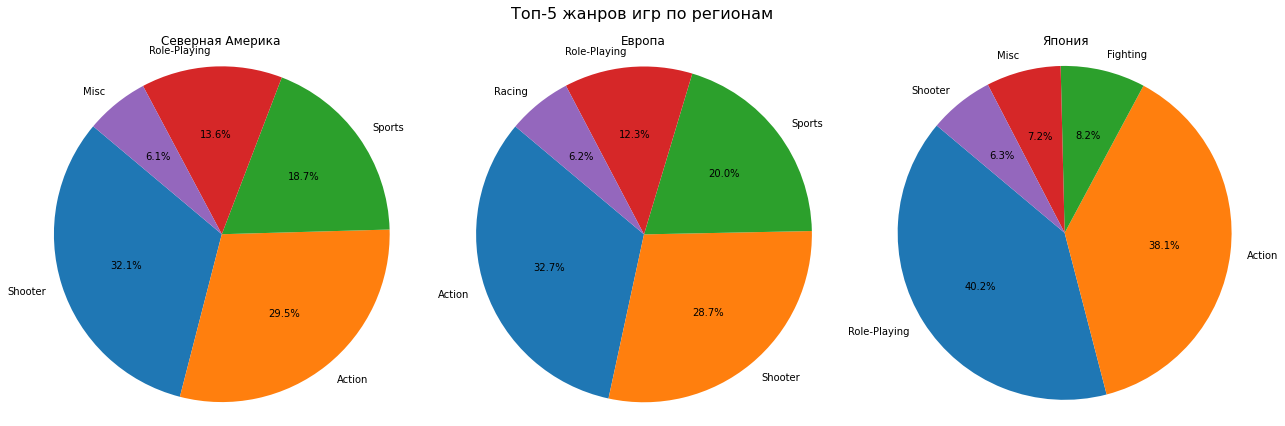

In [57]:
# и также как ив предыдущем случаем построим круговые диаграммы в процентном соотношении
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Топ-5 жанров игр по регионам', fontsize=16)

# Северная Америка
axes[0].pie(
    na['na_sales'],
    labels=na['genre'],
    autopct='%1.1f%%',
    startangle=140
)
axes[0].set_title('Северная Америка')

# Европа
axes[1].pie(
    eu['eu_sales'],
    labels=eu['genre'],
    autopct='%1.1f%%',
    startangle=140
)
axes[1].set_title('Европа')

# Япония
axes[2].pie(
    jp['jp_sales'],
    labels=jp['genre'],
    autopct='%1.1f%%',
    startangle=140
)
axes[2].set_title('Япония')

for ax in axes:
    ax.axis('equal')

plt.tight_layout()
plt.show()

что мы получили на графиках.  
картина во всех регионах разная, по очереди опишем каждую.  

в Северной Америка по предпочтениям жанров игр такое распределение:  
   + на первом месте жанр "Shooter" 32.1%;
   + на втором - "Action" с 29.5%;  
   + на третем - "Sports" с 18.7%;
   + на четвертом - "Role-Playing" с 13.6%;  
   + и на пятом замыкающем - "Misc" с 6.1%.  
    
в Европе:  
   + на первом месте жанр "Action" с 32.7%;  
   + на втором - "Shooter" с 28.7%;
   + на третем - "Sports" с 20.0%;  
   + на четвртом - "Role-Playing" с 12.3%;  
   + и ны пятом - "Racing" с 6.2%.
    
в Японии:  
   + на первом месте жанр "Role-Playing" с 40.2%;  
   + на втором - "Action" с 38.1%;
   + на третем - "Fighting" с 8.2%;  
   + на четвртом - "Misc" с 7.2%;  
   + и ны пятом - "Shooter" с 6.3%.

<b>4.3. Влияние рейтинга ESRB на продажи в отдельном регионе.</b>
<a id='4.3'></a> 

In [58]:
na = current_period[current_period.year_of_release >= 2014].groupby('rating')['na_sales'].agg(na_sales='sum').nlargest(5, 'na_sales').reset_index()
eu = current_period[current_period.year_of_release >= 2014].groupby('rating')['eu_sales'].agg(eu_sales='sum').nlargest(5, 'eu_sales').reset_index()
jp = current_period[current_period.year_of_release >= 2014].groupby('rating')['jp_sales'].agg(jp_sales='sum').nlargest(5, 'jp_sales').reset_index()

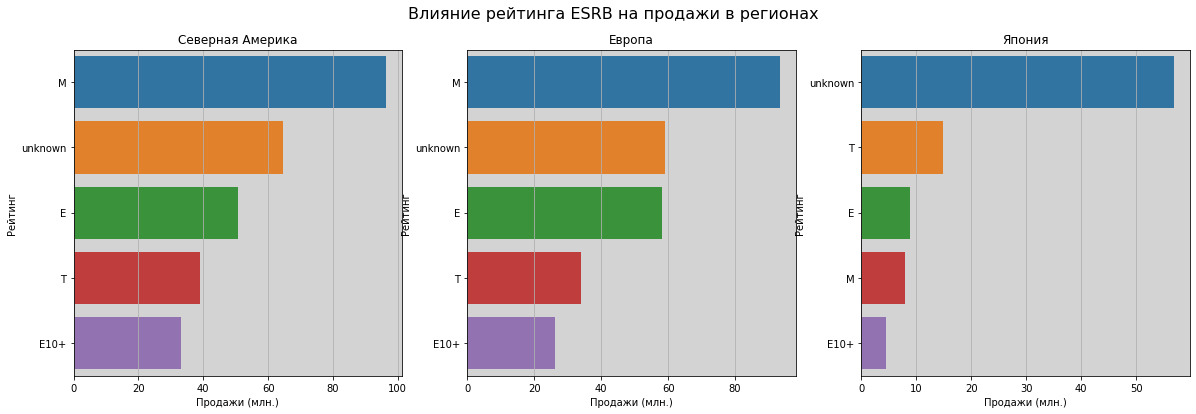

In [59]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Влияние рейтинга ESRB на продажи в регионах', fontsize=16)

# Северная Америка
sns.barplot(y='rating', x='na_sales', data=na, ax=ax[0])
ax[0].set_title('Северная Америка')
ax[0].set_xlabel('Продажи (млн.)')
ax[0].set_ylabel('Рейтинг')
ax[0].grid(axis='x')
ax[0].set_facecolor('lightgray')

# Европа
sns.barplot(y='rating', x='eu_sales', data=eu, ax=ax[1])
ax[1].set_title('Европа')
ax[1].set_xlabel('Продажи (млн.)')
ax[1].set_ylabel('Рейтинг')
ax[1].grid(axis='x')
ax[1].set_facecolor('lightgray')

# Япония
sns.barplot(y='rating', x='jp_sales', data=jp, ax=ax[2])
ax[2].set_title('Япония')
ax[2].set_xlabel('Продажи (млн.)')
ax[2].set_ylabel('Рейтинг')
ax[2].grid(axis='x')
ax[2].set_facecolor('lightgray')

plt.show()

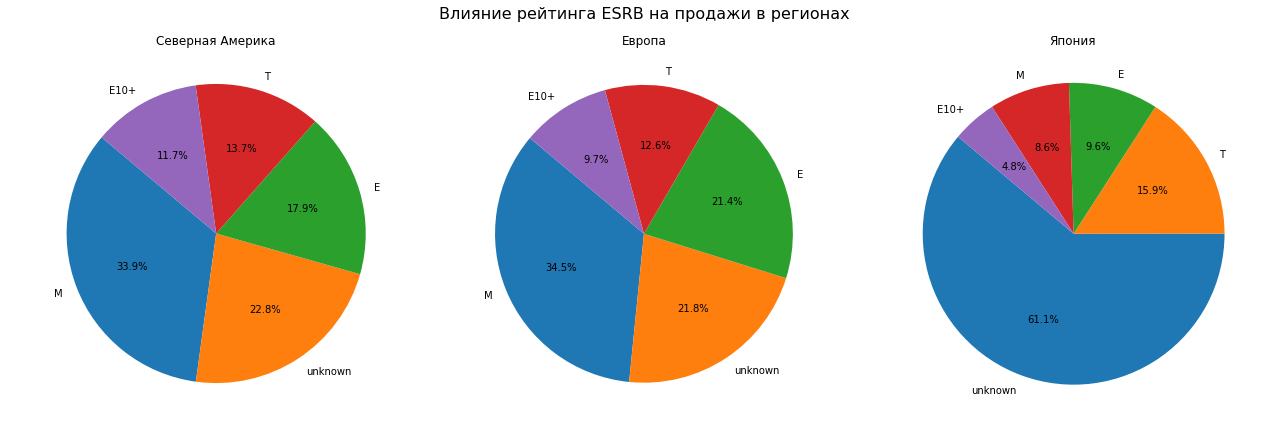

In [60]:
# и круговые
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Влияние рейтинга ESRB на продажи в регионах', fontsize=16)

# Северная Америка
axes[0].pie(
    na['na_sales'],
    labels=na['rating'],
    autopct='%1.1f%%',
    startangle=140
)
axes[0].set_title('Северная Америка')

# Европа
axes[1].pie(
    eu['eu_sales'],
    labels=eu['rating'],
    autopct='%1.1f%%',
    startangle=140
)
axes[1].set_title('Европа')

# Япония
axes[2].pie(
    jp['jp_sales'],
    labels=jp['rating'],
    autopct='%1.1f%%',
    startangle=140
)
axes[2].set_title('Япония')

for ax in axes:
    ax.axis('equal')

plt.tight_layout()
plt.show()

что можем сказать.  

по влиянию рейтинг ESRB на продажи у нас совпали 2 региона - Северная Америка и Европа.  
+ на первом месте по продажам у них идет рейтинг "M" - для взрослых от 17 лет (у СА - 33.9%, у Е - 34.5%);  
+ на втором месте неопределенный рейтинг (у СА - 22.8%, у Е - 21.8%);  
+ на третем месте рейтинг "Е" - для всех (У СА - 17.9%, у Е - 21.4%);  
+ на четвртом метсе рейтинг "Т" - для подростков от 13 лет (у СА - 13.7%, у Е - 12.6%);  
+ и на замыкающем месте рйтинг "Е10+" - для всех старше 10 лет (у СА - 11.7%, у Е - 9.7%).  

в Японии такие же рейтинг влияют на продажи, но уже в другом порядке: 
   + на первом месте неопределенный рейтинг с 61.1%;  
   + на втором рейтинг "Т" - для подростков от 13 лет с 15.9%;  
   + на третем рейтинг "Е" - для всех  9.6%;  
   + на четвертом рейтинг "М" - для взрослых от 17 лет с 8.6%;  
   + и на пятом рейтинг "Е10+" - для всех старше 10 лет с 4.8%.

<b>4.4. Вывод.</b>
<a id='4.4'></a> 

обобщим все выше сказанное для пользователей отдельных регионов.  

+ в Северной Америке более привлекательной платформой считается "PS4", так как продажи составляют около 39% от всех продаж в этом регионе, также еще отметим платформу "XOne", она не так далеко отстает от лидера, ведь продажи составляют 32.1%. Пользователи данного региона предпочитают скупать игры в жанрах "Shooter" и "Action", продажи составляют 32.1% и 29.5% соответственно от всех продаж в данном регионе. Пользователи этого региона предпочитают игры с рейтингом "М", т.е. для взрослых (старше 17 лет), т.к. продажи игр с таким рейтингом составляют 33.9% от всех продаж, и также отметим, что высокий спрос идет на игры с неопределенным рейтингом, у которых продажи составляют 22.8%.  
<b> В целом житель Северной Америки предпочитает играть на платформе "PS4" в игры, у которых жанры "Shooter" и "Action", и с рейтингами "М" (для взрослых старше 17 лет) или неопределенным.</b>  

+ в Европе самой привлекательной платформой-лидером считается "PS4", продажи составляют около 55.1% от всех продаж в этом регионе. Пользователи данного региона предпочитают скупать игры в жанрах "Action" и "Shooter", продажи составляют 32.7% и 28.7% соответственно от всех продаж в данном регионе. Пользователи этого региона предпочитают игры с рейтингом "М", т.е. для взрослых (старше 17 лет), т.к. продажи игр с таким рейтингом составляют 34.5% от всех продаж, и также отметим, что высокий спрос идет на игры с неопределенным рейтингом и рейтингом "Е" - для всех, у которых продажи составляют 21.8% и 21.4% соответственно.   
<b> В целом житель Европы предпочитает играть на платформе "PS4" в игры, у которых жанры "Action" и "Shooter", и с рейтингом "М" (для взрослых старше 17 лет).</b> 

+ в Японии самой привлекательной платформой-лидером считается "3DS", продажи составляют около 47.9% от всех продаж в этом регионе. Пользователи данного региона предпочитают скупать игры в жанрах "Role-Playing" и "Action", продажи составляют 40.2% и 38.1% соответственно от всех продаж в данном регионе. Пользователи этого региона предпочитают игры с неопределенным рейтингом, т.к. продажи игр с таким рейтингом составляют 61.1% от всех продаж.  
<b> В целом житель Японии предпочитает играть на платформе "3DS" в игры, у которых жанры "Role-Playing" и "Action", и с неопределенным рейтингом.</b> 

<h1>5. Проверка гипотез.</h1>
<a id='5'></a>

<b>5.1. Гипотеза: средние пользовательские рейтинги платформ Xbox One и PC одинаковые.</b>
<a id='5.1'></a> 

In [61]:
XOne = current_period.query('platform == "XOne" and user_score > -1')
PC = current_period.query('platform == "PC" and user_score > -1')

в данном случае будем использовать t-тест для независимых выборок.  
у нас большие выборки, подходит для анализа различий в средних значениях между двумя независимыми наборами данных, этот тест позволит определить, есть ли статистически значимая разница между средними двух групп.
ТЗ удовлетворяет условиям для составления нулевой гипотезы, т.е. сравнимаемые величины равны.  
альтернативная гипотеза может быть проверена тремя вариантами "меньше", "не равно", "больше" необходимо проверить вопрос про равенство, следовательно проверку надо провести двухстороннюю alternative='two-sided'.

<i>Основная и альтернативная гипотезы:</i>  
    
<b>Н0:</b> Средние пользовательские рейтинги платформ "XOne" и "PC" равны.  
<b>Н1:</b> Средние пользовательские рейтинги платформ "XOne" и "PC" различаются.

In [62]:
alpha = 0.05

print('средний пользовательский рейтинг платформы "XOne":', round(XOne.query('platform == "XOne"')['user_score'].mean(),2))
print('средний пользовательский рейтинг платформы "PC":', round(PC.query('platform == "PC"')['user_score'].mean(),2))

results = st.ttest_ind(XOne['user_score'], PC['user_score'],equal_var=False,alternative='two-sided')

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print("Отвергаем нулевую гипотезу, средние пользовательские рейтинги платформ 'XOne' и 'PC' различаются")
else:
    print("Не получилось отвергнуть нулевую гипотезу, средние пользовательские рейтинги платформ 'XOne' и 'PC' равны")

средний пользовательский рейтинг платформы "XOne": 6.59
средний пользовательский рейтинг платформы "PC": 6.3
p-значение: 0.11601398086668832
Не получилось отвергнуть нулевую гипотезу, средние пользовательские рейтинги платформ 'XOne' и 'PC' равны


<u>Подвывод:</u>  
    Нет оснований полагать, что средние пользовательские рейтинги платформ "XOne" и "PC" значимо различаются.  
    Разница между средними пользовательскими рейтингами для платформ составляет 0.29 балла, что является не статистически значимым показателем.

<b>5.2. Гипотеза: средние пользовательские рейтинги жанров Action и Sports разные.</b>
<a id='5.2'></a>

In [63]:
Action = current_period.query('genre == "Action" and user_score > -1')
Sports = current_period.query('genre == "Sports" and user_score > -1')

здесь также будем использовать t-тест для независимых выборок.
у нас большие выборки, подходит для анализа различий в средних значениях между двумя независимыми наборами данных, этот тест позволит определить, есть ли статистически значимая разница между средними двух групп.  
ТЗ не удовлетворяет условиям для составления нулевой гипотезы (сравнимаемые параметры равны), для дальнейшего решения лучше повернуть ситуацию.  
альтернативная гипотеза может быть проверена тремя вариантами "меньше", "не равно", "больше" необходимо проверить вопрос про равенство, следовательно проверку надо провести двухстороннюю alternative='two-sided'.

перевернем ситуацию.  
<i>Основная и альтернативная гипотезы:</i>  
    
<b>Н0:</b> Средние пользовательские рейтинги жанров "Action" и "Sports" равны.  
<b>Н1:</b> Средние пользовательские рейтинги платформ жанров "Action" и "Sports" различаются.

In [64]:
alpha = 0.05

print('средний пользовательский рейтинг жанра "Action":', round(Action.query('platform == "XOne"')['user_score'].mean(),2))
print('средний пользовательский рейтинг жанра "Sports":', round(Sports.query('platform == "PC"')['user_score'].mean(),2))

results = st.ttest_ind(Action['user_score'], Sports['user_score'],equal_var=False,alternative='two-sided')

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print("Отвергаем нулевую гипотезу, средние пользовательские рейтинги жанров 'Action' и 'Sports' различаются")
else:
    print("Не получилось отвергнуть нулевую гипотезу, средние пользовательские рейтинги жанров 'Action' и 'Sports' равны")

средний пользовательский рейтинг жанра "Action": 6.7
средний пользовательский рейтинг жанра "Sports": 4.82
p-значение: 1.1825550382644557e-14
Отвергаем нулевую гипотезу, средние пользовательские рейтинги жанров 'Action' и 'Sports' различаются


<u>Подвывод:</u>  
    Имеются основания полагать, что средние пользовательские рейтинги жанров 'Action' и 'Sports' различаются.  
    Разница между средними пользовательскими рейтингами жанров составляет 1.88 балла, что является статистически значимым показателем.

<h1>6. Общий вывод.</h1>
<a id='6'></a>

<b> 1. Мы получили файл с данными "/datasets/games.csv" (который потом переписали в датасет "games") и изучили его. </b>  

Таблица состоит из 16.715 строк и 11 столбцов:  
1) название игры;   
2) платформа;  
3) год выпуска;  
4) жанр игры;  
5) продажи в Северной Америке (миллионы проданных копий);  
6) продажи в Европе (миллионы проданных копий);  
7) продажи в Японии (миллионы проданных копий);  
8) продажи в других странах (миллионы проданных копий);  
9) оценка критиков (максимум 100);  
10) оценка пользователей (максимум 10);  
11) рейтинг от организации ESRB. Эта ассоциация определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию.  

Обнаружили ряд проблем:  
+ проблемы со стилизацией столбцов в представленной нам таблице;  
+ типы данных в некоторых столбцах не соответствуют действительности;  
+ наличие пропусков.

<b> 2. Подготовили полученные данные для дальнейшего исследования. </b>  

2.1. Привели названия столбцов в нашей таблице к нижнему регистру.  

2.2. В некоторых столбцах обнаружили пропуски: 
+ в столбцах с названием игры, годом релиза и жанром игр обнаружены пропуски, такие строки были удалены, т.к. ввиду малого количества этих пропусков это никак не повлияет на исследование;  
+ в столбцах оценок критиков и пользователей обнаружены пропуски, такие строки удалять было нельзя ввиду их большого количества (оказало бы влияние на дальнейшее исследование), по-этому было принято решение поставить заглушки на такие пропуски "-1";  
+ в столбце рейтинга у нас было тоже много пропусков, и удаять такие строки тоже было нельзя, и было принято решение поставить заглушку "unknown" на имеющиеся пропуски.  

2.3. В столбце оценок пользователей мы также обнаружили аббревиатуру "tbd" (to be determined - будет определено) в приличном количестве, так как это неопределенные значения, мы их приравняли к пропускам, по-этому приплюсовали их к нашей заглушке "-1".

2.4. Причины, которые могли привести к наличию пропусков в представленных нам данных:
в названиях игр:  
+ человеческий фактор (недостаточная или некорректная информация при сборе данных);  
+ компьютерный фактор (неправильное форматирование данных, ошибка при импорте).
в годах релиза:
+ отсутствие данных о дате релиза;
+ дата релиза может быть не зафиксирована в целом для игр, выпущенных в ограниченном количестве в определенных регионах.
в жанрах игр:
+ отсутствие классификации жанров для некоторых игр;
+ смешанные жанры игры, которые сложно классифицировать;
+ человеческий фактор (ошибки и пропуски при сборе информации).
в оценках критиков:
+ человеческий фактор (ошибки при сборе данных);
+ отсутствие отзывов критиков (для новых или малоизвестных игр).
в оценках пользователей:
+ недостаточное количество отзывов;
+ отсутствие отзывов (для новых недавно выпущенных игр);
+ человеческий фактор (ошибки при сборе данных);
+ компьютерный фактор (неправильная модерация отзывов).
и в рейтингах:
+ человеческий фактор (ошибки при сборе данных);
+ не все игры проходят процедуру присвоения рейтинга;
+ отсутствие рейтинга (для новых недавно выпущенных игр);
+ компьютерный фактор (ошибки при обработке и импорте данных).

2.5 Также был осуществлен поиск дубликатов, в ходе поиска была обнаружена 1 строка во всем нашем датасете дублирующая сама себя. Она была удалена, так как для дальнейшего исследования она нам не нужна, так как никак не повлияет на дальнейшее исследование.

2.6. Мы исправили в некоторых столбцах типы данных на соответствующие действительности:  
+ в столбце с годами релиза тип данных исправили на "int";
+ в столбцах с оценками критиков и пользователей исправили на "float".

2.7. Добавили новый столбец с посчитанными суммарными продажами во всех регионами.

<b> 3. Провели исследовательский анализ данных в соответствии с ТЗ. </b> 

3.1. Рассмотрели динамику выпуска количества игр по годам.
С 1980 года по 1991 год развитие игр было слабым, начиная с 1991 года вплоть до 2009 года отметили значительный рост количества выпускаемых игр, рост связан с развитием игр и набора популярности у пользователей (компьютеры в эти годы стало проще покупать). После 2009 года количество выпускаемых игр сокращается, может быть связано с большой конкурентностью на рынке (разработчики стараются максимально улучшить игру, по-этому выпускают реже).   
Минимальное количество игр (9 шт.) выпущено в 1980 году.  
Максимальное количество игр (1.427 шт.) выпущено в 2008 году.  
Данные за каждый период нам важны, так как прослеживается динамика разработки и выпуска игр.

3.2. Рассмотрели динамику продаж по платформам:  
+ определили неоспоримого лидера по продажам - платформа "PS2", более 1.233 миллионов проданных копий;  
+ на втором месте "X360" с более 961 миллионом проданных копий;
+ на третем месте "РS3" с более 931 миллионом проданных копий;
+ на четвертом месте "Wii" с более 891 миллионом проданных копий;
+ на пятом месте "DS" с более 802 миллионами проданных копий;
+ и на шестом месте "РS" с более 727 миллионов проданных копий.  
У оставшихся платформ продажи значительно ниже. 

3.3. После определения этих 6 лидеров мы смотрели их распределения по годам и определили, что средний срок жизни платформы составляет 10 лет, в среднем популярности (пикового значения) каждая платформа достигает в среднем через 5 лет после выхода на рынок, после чего идет на спад.  
+ у платформы "РS2" пик продаж приходится с 2002 года по 2004 год;
+ у платформы "Х360" пик продаж был в 2010 году;
+ у платформы "РS3" хорошие продажи были с 2008 года по 2011 год;
+ у платформы "Wii" пик продаж был в 2009 году;
+ у платформы "DS" хорошие продажи были с 2005 года по 2008 год;
+ и у платформы "РS" пик приходится на 1998 год. 
Отметили, что даже уже наши лидеры-платформы на данный момент не являются актуальными.

3.4. Для прогнозирования продаж на 2017 год нами был выбран актуальный период для исследования - последние 3 года (2014 год, 2015 год и 2016 год).  
На актуальный период в лидерах по продажам у нас платформа "РS4" с продажами более 288 миллионов копий.  
На втором месте за актуальный период - платфора "XOne" с продажами более 140 миллионов копий.  
У остальных платформ показатели продаж значительно ниже. Картина выгядит негативно в целом для всех платформ.  
Свою привлекательность потеряли платформы: "3DS", "PS3", "Х360", "WiiU", "РС", "PSV", "Wii" и "PSP".  
Платформы "PS4" и "XOne" оставляют надежды хотя бы на непадение своей популярности, их мы и считаем потенциально прибыльными платформами.

3.5. Построили "ящики с усами" по глобальным продажам в разбивке по платформам отметили следующее:
+ все платформы имеют выбросы;
+ распределение продаж среди платформ примерно одинаковое;
+ медиана продаж у всех находится примерно на одном уровне (0.2).

3.6. Для оценки влияния отзывов пользователей и критиков на продажи внутри одной популярной платформы мы выбрали платформу "PS4". Построили диаграммы рассеивания, а также подсчитали результаты. и получили следующее: рейтинг критиков и продажи имеют корреляцию около 40, можно сказать, что существует положительная связь между рейтингом критиков и продажами, чем выше оценка критиков, тем лучше продажи, а вот про рейтинг пользователей можно сказать, что вообще никак не влияет на продажи. в целом рейтинги — не единственный или главный фактор, влияющий на продажи игр.


3.7. Также нами были рассмотрены еще 4 менее популярные платформы: "XOne", "3DS", "PS3" и "Х360". И при сравнении с лидером-платформой "PS4" разницы особо нет. Оценка критиков также оказывает влияние на продажи, у рассмотренных нами корреляция больше 30%, в случае платформы "Х360" так вообще все 53%. По поводу оценок пользователей корреляция во всех случаях меньше 22%, что говорит о ничтожно малой зависимости с продажами. В целом можно сказать, что к мнению критиков люди прислушиваются больше.
    
    
3.8. При распределении игр по жанрам (распределяли по медианным продажам за актуальный период) выявили следующее:  
+ лидер по медианным продажам за актуавльный период - жанр игры "Shooter" (0.52 миллионов проданных копий), высокая популярность и устойчивый спрос, следовательно продажи выше, чем у других жанров;  
+ на втором месте расположился жанр игры "Sports", хоть и показатель медианных продаж значительно ниже, чем у жанра "Shooter", но тем не менее тоже пользуется стабильным интересом у пользователей (0.18 миллионов проданных копий) за актуальный период;  
+ самые низкие медианные продажи у нас показывают такие жанры как: ""Adventure", "Puzzle" и "Strategy" (0.03, 0.04 и 0.06 миллионов проданных копий соответственно).

<b> 4. Составили портреты пользователей для каждого региона. </b>

+ житель Северной Америки предпочитает играть на платформе "PS4" в игры, у которых жанры "Shooter" и "Action", и с рейтингами "М" (для взрослых старше 17 лет) или с неопределенным рейтингом;
+ житель Европы предпочитает играть на платформе "PS4" в игры, у которых жанры "Action" и "Shooter", и с рейтингом "М" (для взрослых старше 17 лет);  
+ житель Японии предпочитает играть на платформе "3DS" в игры, у которых жанры "Role-Playing" и "Action", и с неопределенным рейтингом.

<b> 5. Проверили выдвинутые гипотезы. </b>

5.1. Гипотеза: средние пользовательские рейтинги платформ Xbox One и PC одинаковые.  
Нет оснований полагать, что средние пользовательские рейтинги платформ "XOne" и "PC" значимо различаются.
Разница между средними пользовательскими рейтингами для платформ составляет 0.29 балла, что является не статистически значимым показателем.

5.2. Гипотеза: средние пользовательские рейтинги жанров Action и Sports разные.  
Имеются основания полагать, что средние пользовательские рейтинги жанров "Action" и "Sports" различаются.
Разница между средними пользовательскими рейтингами жанров составляет 1.88 балла, что является статистически значимым показателем.

<b> 6. Рекомендации. </b>

После проведенного исследования за актуальный период (2014-2016 гг.) для прогнозирования на 2017 год можно сказать следующее:  
+ Потенциально популярный продукт и рекламные кампании должны быть направлены на платформы "PS4", "XOne". 
+ Разрабатывать игры жанров "Action", "Schooter" и "Sports" для западных регионов. 
+ Для воточных регионов упор делать на играх жанров "Role-Playing" и "Action". 
+ Игры направить на рейтинговые категории "М" (для взрослых старше 17 лет), "Е" (для всех), "Т" (для подростков старше 13 лет).
+ Разработчикам игр стоит обратить внимание на жанры с высокими медианными продажами для создания новых проектов, так как они могут иметь больший потенциал для успеха.